In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from matplotlib import pyplot as plt

# Load the dataset
df = pd.read_csv('/content/Accidental_Drug_Related_Deaths.csv')

print("Dataset loaded successfully. Displaying the first 5 rows:")
display(df.head())

Dataset loaded successfully. Displaying the first 5 rows:


,Date,Date Type,Age,Sex,Race,Ethnicity,Residence City,Residence County,Residence State,Injury City,...,Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,ResidenceCityGeo,InjuryCityGeo,DeathCityGeo
0,05/29/2012,Date of death,37.0,Male,Black,NaN,STAMFORD,FAIRFIELD,NaN,STAMFORD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"STAMFORD, CT\n(41.051924, -73.539475)","STAMFORD, CT\n(41.051924, -73.539475)","CT\n(41.575155, -72.738288)"
1,06/27/2012,Date of death,37.0,Male,White,NaN,NORWICH,NEW LONDON,NaN,NORWICH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"NORWICH, CT\n(41.524304, -72.075821)","NORWICH, CT\n(41.524304, -72.075821)","Norwich, CT\n(41.524304, -72.075821)"
2,03/24/2014,Date of death,28.0,Male,White,NaN,HEBRON,NaN,NaN,HEBRON,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"HEBRON, CT\n(41.658069, -72.366324)","HEBRON, CT\n(41.658069, -72.366324)","Marlborough, CT\n(41.632043, -72.461309)"
3,12/31/2014,Date of death,26.0,Female,White,NaN,BALTIC,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"BALTIC, CT\n(41.617221, -72.085031)","CT\n(41.575155, -72.738288)","Baltic, CT\n(41.617221, -72.085031)"
4,01/16/2016,Date of death,41.0,Male,White,NaN,SHELTON,FAIRFIELD,CT,SHELTON,...,NaN,NaN,NaN,NaN,NaN,Y,NaN,"SHELTON, CT\n(41.316843, -73.092968)","SHELTON, CT\n(41.316843, -73.092968)","Bridgeport, CT\n(41.179195, -73.189476)"


In [ ]:
print("\nMissing values before cleaning:")
display(df.isnull().sum()[df.isnull().sum() > 0])

# Define drug columns that will be handled separately (Naively assuming the drug_columns variable exists from a later cell)
drug_columns = [
    'Heroin', 'Heroin death certificate (DC)', 'Cocaine', 'Fentanyl',
    'Fentanyl Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone',
    'Benzodiazepine', 'Methadone', 'Meth/Amphetamine', 'Amphet', 'Tramad',
    'Hydromorphone', 'Morphine (Not Heroin)', 'Xylazine', 'Gabapentin',
    'Opiate NOS', 'Heroin/Morph/Codeine', 'Other Opioid', 'Any Opioid', 'Other'
]

# Separate numerical and categorical columns for imputation, excluding drug columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

# Filter out drug columns from imputation lists
numerical_cols_to_impute = [col for col in numerical_cols if col not in drug_columns]
categorical_cols_to_impute = [col for col in categorical_cols if col not in drug_columns]

# Impute non-drug numerical columns with the median
for col in numerical_cols_to_impute:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# Impute non-drug categorical columns with the mode
for col in categorical_cols_to_impute:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)

print("\nMissing values after general cleaning (drug columns not imputed here):")
display(df.isnull().sum()[df.isnull().sum() > 0])


Missing values before cleaning:


,0
Age,2
Sex,9
Race,57
Ethnicity,9416
Residence City,596
Residence County,1260
Residence State,1988
Injury City,178
Injury County,3334
Injury State,3029


/tmp/ipykernel_185/278512607.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_185/278512607.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.


Missing values after general cleaning (drug columns not imputed here):


,0
Heroin,8403
Heroin death certificate (DC),11241
Cocaine,7403
Fentanyl,3932
Fentanyl Analogue,11007
Oxycodone,10965
Oxymorphone,11819
Ethanol,8780
Hydrocodone,11812
Benzodiazepine,9264


In [ ]:
original_columns = df.columns.tolist()
df.columns = df.columns.str.strip()

renamed_columns = {old: new for old, new in zip(original_columns, df.columns) if old != new}
if renamed_columns:
    print("Renamed columns with trailing spaces:")
    for old, new in renamed_columns.items():
        print(f"  '{old}' -> '{new}'")
else:
    print("No columns with trailing spaces found.")

print("\nDisplaying updated column names:")
print(df.columns.tolist())

Renamed columns with trailing spaces:
  'Other Significant Conditions ' -> 'Other Significant Conditions'

Displaying updated column names:
['Date', 'Date Type', 'Age', 'Sex', 'Race', 'Ethnicity', 'Residence City', 'Residence County', 'Residence State', 'Injury City', 'Injury County', 'Injury State', 'Injury Place', 'Description of Injury', 'Death City', 'Death County', 'Death State', 'Location', 'Location if Other', 'Cause of Death', 'Manner of Death', 'Other Significant Conditions', 'Heroin', 'Heroin death certificate (DC)', 'Cocaine', 'Fentanyl', 'Fentanyl Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Meth/Amphetamine', 'Amphet', 'Tramad', 'Hydromorphone', 'Morphine (Not Heroin)', 'Xylazine', 'Gabapentin', 'Opiate NOS', 'Heroin/Morph/Codeine', 'Other Opioid', 'Any Opioid', 'Other', 'ResidenceCityGeo', 'InjuryCityGeo', 'DeathCityGeo']


In [ ]:
if 'Age' in df.columns:
    # Ensure 'Age' is numeric, coercing errors will turn non-numeric into NaN
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    # Impute NaNs that might have been introduced by coercion
    if df['Age'].isnull().any():
        df['Age'].fillna(df['Age'].median(), inplace=True)

    scaler = StandardScaler()
    df['Age_scaled'] = scaler.fit_transform(df[['Age']])
    print("\n'Age' column scaled. Displaying original and scaled 'Age' values:")
    display(df[['Age', 'Age_scaled']].head())
else:
    print("The 'Age' column was not found in the dataset.")


'Age' column scaled. Displaying original and scaled 'Age' values:


,Age,Age_scaled
0,37.0,-0.553051
1,37.0,-0.553051
2,28.0,-1.262982
3,26.0,-1.420745
4,41.0,-0.237526


In [ ]:
if 'Race' in df.columns:
    # Standardize race names to lowercase and strip spaces for consistent mapping
    df['Race'] = df['Race'].str.lower().str.strip()

    # Define a mapping for race supergroups
    race_supergroup_map = {
        'white': 'White',
        'black': 'Black/African American',
        'hispanic': 'Hispanic/Latino',
        'asian': 'Asian',
        'american indian': 'Native American/Alaskan Native',
        'native american': 'Native American/Alaskan Native',
        'other': 'Other',
        'unknown': 'Unknown'
    }

    def map_race_to_supergroup(race):
        for key, supergroup in race_supergroup_map.items():
            if key in race:
                return supergroup
        return 'Unknown' # Default for unmapped races

    df['Race_Supergroup'] = df['Race'].apply(map_race_to_supergroup)

    print("\n'Race' grouped into supergroups. Displaying original 'Race' and new 'Race_Supergroup' counts:")
    print("Original Race counts:")
    display(df['Race'].value_counts())
    print("\nRace Supergroup counts:")
    display(df['Race_Supergroup'].value_counts())
else:
    print("The 'Race' column was not found in the dataset.")


'Race' grouped into supergroups. Displaying original 'Race' and new 'Race_Supergroup' counts:
Original Race counts:


,count
Race,
white,10139
black or african american,826
black,809
unknown,62
other,52
asian indian,26
"asian, other",24
other (specify),13
other asian,12



Race Supergroup counts:


,count
Race_Supergroup,
White,10139
Black/African American,1636
Asian,70
Other,68
Unknown,66
Native American/Alaskan Native,2


In [ ]:
if 'Sex' in df.columns:
    # Standardize 'Sex' values
    df['Sex'] = df['Sex'].astype(str).str.lower().str.strip()

    def standardize_sex(sex_val):
        if 'm' in sex_val: # Catches male, m, MALE, etc.
            return 'Male'
        elif 'f' in sex_val: # Catches female, f, FEMALE, etc.
            return 'Female'
        else:
            return 'Unknown'

    df['Sex_Standardized'] = df['Sex'].apply(standardize_sex)

    print("\n'Sex' column standardized. Original vs. standardized counts:")
    print("Original Sex counts:")
    display(df['Sex'].value_counts())
    print("\nStandardized Sex counts:")
    display(df['Sex_Standardized'].value_counts())

    # Apply numerical encoding (0, 1, 2)
    sex_mapping = {'Male': 0, 'Female': 1, 'Unknown': 2}
    df['Sex_Encoded'] = df['Sex_Standardized'].map(sex_mapping)

    print("\n'Sex' column numerically encoded. Displaying new 'Sex_Encoded' values and counts:")
    display(df[['Sex_Standardized', 'Sex_Encoded']].head())
    display(df['Sex_Encoded'].value_counts())
else:
    print("The 'Sex' column was not found in the dataset.")

print("\nPreprocessing complete. Displaying the first 5 rows of the updated DataFrame:")
display(df.head())


'Sex' column standardized. Original vs. standardized counts:
Original Sex counts:


,count
Sex,
male,8896
female,3082
unknown,2
x,1



Standardized Sex counts:


,count
Sex_Standardized,
Male,11978
Unknown,3



'Sex' column numerically encoded. Displaying new 'Sex_Encoded' values and counts:


,Sex_Standardized,Sex_Encoded
0,Male,0
1,Male,0
2,Male,0
3,Male,0
4,Male,0


,count
Sex_Encoded,
0,11978
2,3



Preprocessing complete. Displaying the first 5 rows of the updated DataFrame:


,Date,Date Type,Age,Sex,Race,Ethnicity,Residence City,Residence County,Residence State,Injury City,...,Other Opioid,Any Opioid,Other,ResidenceCityGeo,InjuryCityGeo,DeathCityGeo,Age_scaled,Race_Supergroup,Sex_Standardized,Sex_Encoded
0,05/29/2012,Date of death,37.0,male,black,Hispanic,STAMFORD,FAIRFIELD,CT,STAMFORD,...,NaN,NaN,NaN,"STAMFORD, CT\n(41.051924, -73.539475)","STAMFORD, CT\n(41.051924, -73.539475)","CT\n(41.575155, -72.738288)",-0.553051,Black/African American,Male,0
1,06/27/2012,Date of death,37.0,male,white,Hispanic,NORWICH,NEW LONDON,CT,NORWICH,...,NaN,NaN,NaN,"NORWICH, CT\n(41.524304, -72.075821)","NORWICH, CT\n(41.524304, -72.075821)","Norwich, CT\n(41.524304, -72.075821)",-0.553051,White,Male,0
2,03/24/2014,Date of death,28.0,male,white,Hispanic,HEBRON,NEW HAVEN,CT,HEBRON,...,NaN,NaN,NaN,"HEBRON, CT\n(41.658069, -72.366324)","HEBRON, CT\n(41.658069, -72.366324)","Marlborough, CT\n(41.632043, -72.461309)",-1.262982,White,Male,0
3,12/31/2014,Date of death,26.0,female,white,Hispanic,BALTIC,NEW HAVEN,CT,HARTFORD,...,NaN,NaN,NaN,"BALTIC, CT\n(41.617221, -72.085031)","CT\n(41.575155, -72.738288)","Baltic, CT\n(41.617221, -72.085031)",-1.420745,White,Male,0
4,01/16/2016,Date of death,41.0,male,white,Hispanic,SHELTON,FAIRFIELD,CT,SHELTON,...,NaN,Y,NaN,"SHELTON, CT\n(41.316843, -73.092968)","SHELTON, CT\n(41.316843, -73.092968)","Bridgeport, CT\n(41.179195, -73.189476)",-0.237526,White,Male,0


In [ ]:
drug_columns = [
    'Heroin', 'Heroin death certificate (DC)', 'Cocaine', 'Fentanyl',
    'Fentanyl Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone',
    'Benzodiazepine', 'Methadone', 'Meth/Amphetamine', 'Amphet', 'Tramad',
    'Hydromorphone', 'Morphine (Not Heroin)', 'Xylazine', 'Gabapentin',
    'Opiate NOS', 'Heroin/Morph/Codeine', 'Other Opioid', 'Any Opioid', 'Other'
]

# Function to convert various indicators to binary
def to_binary_drug_involvement(value):
    if pd.isna(value) or str(value).strip().lower() in ['', '0', 'n', 'no']:
        return 0
    else:
        # Assuming any non-empty, non-zero, non-'n' value indicates involvement
        return 1

print("Converting drug-related columns to binary (1 for involvement, 0 for no involvement)...")

for col in drug_columns:
    if col in df.columns:
        df[col] = df[col].apply(to_binary_drug_involvement)
        print(f"  '{col}' converted. Value counts:")
        display(df[col].value_counts())
    else:
        print(f"  Warning: Drug column '{col}' not found in DataFrame.")

print("\nBinary conversion for drug columns complete. Displaying first 5 rows with updated drug columns:")
display(df[drug_columns].head())

Converting drug-related columns to binary (1 for involvement, 0 for no involvement)...
  'Heroin' converted. Value counts:


,count
Heroin,
0,8403
1,3578


  'Heroin death certificate (DC)' converted. Value counts:


,count
Heroin death certificate (DC),
0,11241
1,740


  'Cocaine' converted. Value counts:


...

,count
Any Opioid,
1,8828
0,3153


  'Other' converted. Value counts:


,count
Other,
0,11195
1,786



Binary conversion for drug columns complete. Displaying first 5 rows with updated drug columns:


,Heroin,Heroin death certificate (DC),Cocaine,Fentanyl,Fentanyl Analogue,Oxycodone,Oxymorphone,Ethanol,Hydrocodone,Benzodiazepine,...,Tramad,Hydromorphone,Morphine (Not Heroin),Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other
0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


# Polynomial Regression

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print(" 'Date' column converted to datetime format.")
display(df['Date'].head())

 'Date' column converted to datetime format.


,Date
0,2012-05-29
1,2012-06-27
2,2014-03-24
3,2014-12-31
4,2016-01-16


In [ ]:
# Create a 'poly_substance_indicator'
# Sum the numerical drug indicator columns; if sum > 1, it's poly-substance (1), else 0.
# Ensure only existing drug columns are used for summation to avoid errors.
existing_drug_cols = [col for col in drug_columns if col in df.columns]
df['poly_substance_indicator'] = (df[existing_drug_cols].sum(axis=1) > 1).astype(int)
print("Poly-substance indicator created.")

Poly-substance indicator created.


In [ ]:
# 1. Convert the 'Date' column in the DataFrame df to monthly periods
df['Month'] = df['Date'].dt.to_period('M')

# 2. Group the DataFrame df by the 'Month' column and calculate the sum of 'poly_substance_indicator' and 'Fentanyl'
# Ensure 'Fentanyl' column exists. It was created in previous steps.
monthly_trends = df.groupby('Month')[['poly_substance_indicator', 'Fentanyl']].sum().reset_index()

print("Monthly trends DataFrame created:")
print(monthly_trends.head())

Monthly trends DataFrame created:
     Month  poly_substance_indicator  Fentanyl
0  2012-01                        14         0
1  2012-02                        12         1
2  2012-03                        11         1
3  2012-04                        22         1
4  2012-05                        11         1


In [ ]:
# 3. Create a numerical representation of time
# Convert 'Month' to an integer format (e.g., months since the start)
# The 'Month' column is already a Period object, which can be directly converted to int representing month count from a reference.
monthly_trends['Month_Numerical'] = (monthly_trends['Month'] - monthly_trends['Month'].min()).apply(lambda x: x.n)

print("Numerical representation of Month created:")
print(monthly_trends.head())

Numerical representation of Month created:
     Month  poly_substance_indicator  Fentanyl  Month_Numerical
0  2012-01                        14         0                0
1  2012-02                        12         1                1
2  2012-03                        11         1                2
3  2012-04                        22         1                3
4  2012-05                        11         1                4


In [ ]:
# 4. Define the independent variable X as the numerical time representation
# and the dependent variable y as the monthly sum of 'poly_substance_indicator'
X = monthly_trends[['Month_Numerical']]
y = monthly_trends['poly_substance_indicator']

print("Independent variable X and dependent variable y defined.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print("First 5 rows of X:")
print(X.head())
print("First 5 rows of y:")
print(y.head())

Independent variable X and dependent variable y defined.
Shape of X: (144, 1)
Shape of y: (144,)
First 5 rows of X:
   Month_Numerical
0                0
1                1
2                2
3                3
4                4
First 5 rows of y:
0    14
1    12
2    11
3    22
4    11
Name: poly_substance_indicator, dtype: int64


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 6. Instantiate PolynomialFeatures with a degree of 3. Transform X using this object to create polynomial features.
poly_features = PolynomialFeatures(degree=3)
X_poly = poly_features.fit_transform(X)

print("Polynomial features created.")
print(f"Shape of X_poly: {X_poly.shape}")
print("First 5 rows of X_poly (showing original and squared term):")
print(X_poly[:5])

# 7. Instantiate LinearRegression and fit the model using the transformed polynomial features and y
model = LinearRegression()
model.fit(X_poly, y)

print("Polynomial Regression model fitted successfully.")

Polynomial features created.
Shape of X_poly: (144, 4)
First 5 rows of X_poly (showing original and squared term):
[[ 1.  0.  0.  0.]
 [ 1.  1.  1.  1.]
 [ 1.  2.  4.  8.]
 [ 1.  3.  9. 27.]
 [ 1.  4. 16. 64.]]
Polynomial Regression model fitted successfully.


In [ ]:
# 8. Generate predictions using the fitted polynomial regression model on the transformed X
y_pred = model.predict(X_poly)

print("Predictions generated successfully.")
print(f"Shape of predictions: {y_pred.shape}")
print("First 5 predictions:")
print(y_pred[:5])

Predictions generated successfully.
Shape of predictions: (144,)
First 5 predictions:
[10.52374579 11.11692702 11.73304098 12.37161997 13.03219625]


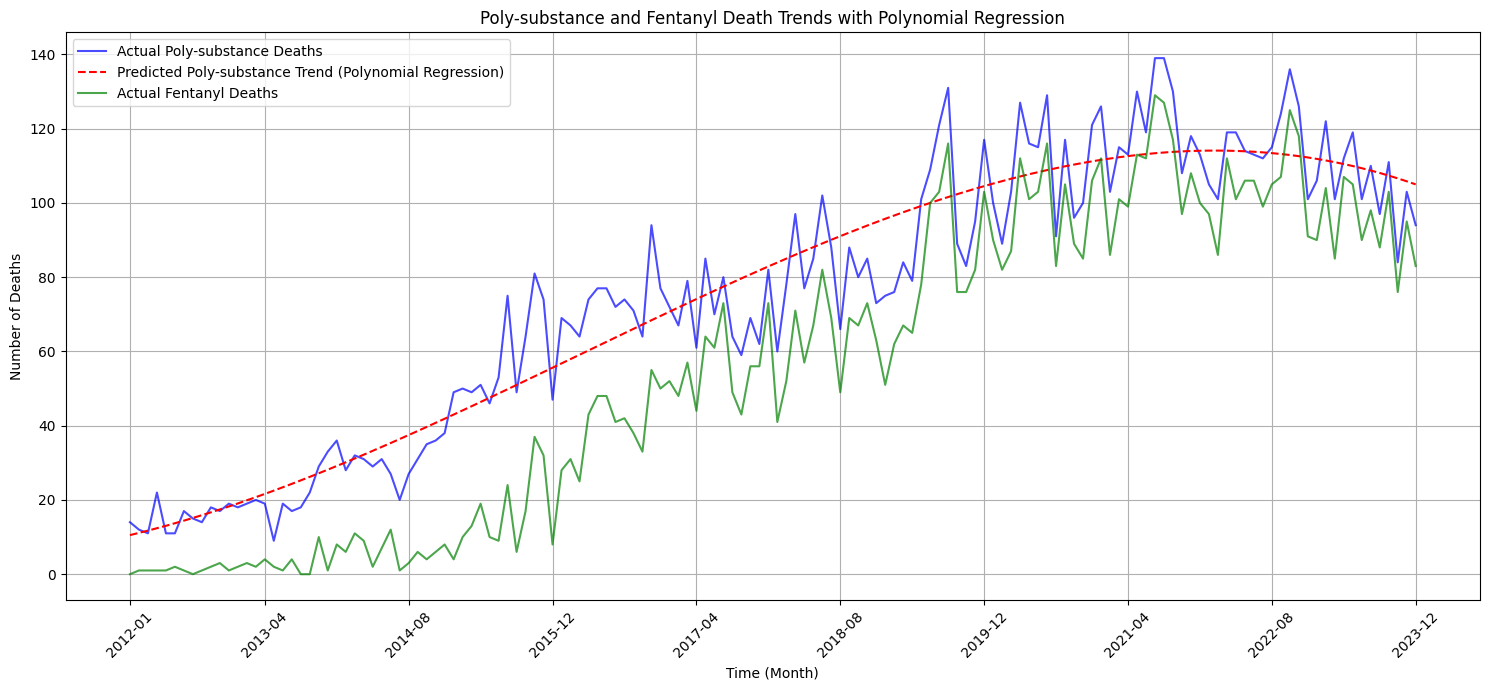

In [ ]:
# 9. Visualize the actual monthly poly-substance deaths and the predicted polynomial trend line.
# Overlay the actual monthly Fentanyl deaths on the same plot.

plt.figure(figsize=(15, 7))

# Plot actual monthly poly-substance deaths
plt.plot(monthly_trends['Month'].astype(str), monthly_trends['poly_substance_indicator'],
         label='Actual Poly-substance Deaths', color='blue', alpha=0.7)

# Plot predicted polynomial trend line
plt.plot(monthly_trends['Month'].astype(str), y_pred,
         label='Predicted Poly-substance Trend (Polynomial Regression)', color='red', linestyle='--')

# Plot actual monthly Fentanyl deaths
plt.plot(monthly_trends['Month'].astype(str), monthly_trends['Fentanyl'],
         label='Actual Fentanyl Deaths', color='green', alpha=0.7)

# Set labels and title
plt.xlabel('Time (Month)')
plt.ylabel('Number of Deaths')
plt.title('Poly-substance and Fentanyl Death Trends with Polynomial Regression')
plt.legend()
plt.grid(True)

# Improve readability of x-axis ticks for time series data
# Show fewer x-axis ticks to prevent overlap
n_ticks = 10 # Number of ticks to display
tick_indices = np.linspace(0, len(monthly_trends) - 1, n_ticks, dtype=int)
plt.xticks(monthly_trends['Month'].astype(str).iloc[tick_indices], rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Evaluate the model performance for the monthly trends (degree 3 polynomial)
mse_monthly_trend = mean_squared_error(y, y_pred)
r2_monthly_trend = r2_score(y, y_pred)
rmse_monthly_trend = np.sqrt(mse_monthly_trend)

print(f"Mean Squared Error (MSE) for monthly poly-substance trend (Degree 3): {mse_monthly_trend:.4f}")
print(f"Root Mean Squared Error (RMSE) for monthly poly-substance trend (Degree 3): {rmse_monthly_trend:.4f}")
print(f"R-squared (R2) for monthly poly-substance trend (Degree 3): {r2_monthly_trend:.4f}")

Mean Squared Error (MSE) for monthly poly-substance trend (Degree 3): 134.0865
Root Mean Squared Error (RMSE) for monthly poly-substance trend (Degree 3): 11.5796
R-squared (R2) for monthly poly-substance trend (Degree 3): 0.9018


In [ ]:
from sklearn.linear_model import Ridge, Lasso
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

print("\n--- Ridge Regression Model (Polynomial Degree 3) ---")

# Initialize and train the Ridge Regression model
# We'll use a default alpha (regularization strength) for initial comparison.
# In a real-world scenario, alpha would be tuned using cross-validation.
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_poly, y)

# Generate predictions
y_pred_ridge = ridge_model.predict(X_poly)

# Evaluate the Ridge model
mse_ridge = mean_squared_error(y, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y, y_pred_ridge)

print(f"Mean Squared Error (MSE) for Ridge: {mse_ridge:.4f}")
print(f"Root Mean Squared Error (RMSE) for Ridge: {rmse_ridge:.4f}")
print(f"R-squared (R2) for Ridge: {r2_ridge:.4f}")

print("\n--- Lasso Regression Model (Polynomial Degree 3) ---")

# Initialize and train the Lasso Regression model
# Again, using a default alpha. Alpha tuning is important for Lasso.
lasso_model = Lasso(alpha=0.1, max_iter=10000) # Increased max_iter to prevent convergence warning
lasso_model.fit(X_poly, y)

# Generate predictions
y_pred_lasso = lasso_model.predict(X_poly)

# Evaluate the Lasso model
mse_lasso = mean_squared_error(y, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y, y_pred_lasso)

print(f"Mean Squared Error (MSE) for Lasso: {mse_lasso:.4f}")
print(f"Root Mean Squared Error (RMSE) for Lasso: {rmse_lasso:.4f}")
print(f"R-squared (R2) for Lasso: {r2_lasso:.4f}")


--- Ridge Regression Model (Polynomial Degree 3) ---
Mean Squared Error (MSE) for Ridge: 134.0865
Root Mean Squared Error (RMSE) for Ridge: 11.5796
R-squared (R2) for Ridge: 0.9018

--- Lasso Regression Model (Polynomial Degree 3) ---
Mean Squared Error (MSE) for Lasso: 134.0871
Root Mean Squared Error (RMSE) for Lasso: 11.5796
R-squared (R2) for Lasso: 0.9018


In [ ]:
print("\n--- Model Performance Comparison (Monthly Poly-substance Trend) ---")
print(f"Standard Linear Regression (Poly Degree {poly_features.degree}):")
print(f"  MSE: {mse_monthly_trend:.4f}")
print(f"  RMSE: {rmse_monthly_trend:.4f}")
print(f"  R2: {r2_monthly_trend:.4f}")

print("\nRidge Regression (Poly Degree 3):")
print(f"  MSE: {mse_ridge:.4f}")
print(f"  RMSE: {rmse_ridge:.4f}")
print(f"  R2: {r2_ridge:.4f}")

print("\nLasso Regression (Poly Degree 3):")
print(f"  MSE: {mse_lasso:.4f}")
print(f"  RMSE: {rmse_lasso:.4f}")
print(f"  R2: {r2_lasso:.4f}")


--- Model Performance Comparison (Monthly Poly-substance Trend) ---
Standard Linear Regression (Poly Degree 3):
  MSE: 134.0865
  RMSE: 11.5796
  R2: 0.9018

Ridge Regression (Poly Degree 3):
  MSE: 134.0865
  RMSE: 11.5796
  R2: 0.9018

Lasso Regression (Poly Degree 3):
  MSE: 134.0871
  RMSE: 11.5796
  R2: 0.9018


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Train a simple Linear Regression model (degree 1) on Month_Numerical
linear_model = LinearRegression()
linear_model.fit(X, y)

# Generate predictions for the linear model
y_pred_linear = linear_model.predict(X)

# Evaluate the linear model
mse_linear = mean_squared_error(y, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y, y_pred_linear)

print("\n--- Linear Regression Model (Degree 1) Performance ---")
print(f"Mean Squared Error (MSE): {mse_linear:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear:.4f}")
print(f"R-squared (R2): {r2_linear:.4f}")


--- Linear Regression Model (Degree 1) Performance ---
Mean Squared Error (MSE): 213.6281
Root Mean Squared Error (RMSE): 14.6160
R-squared (R2): 0.8436


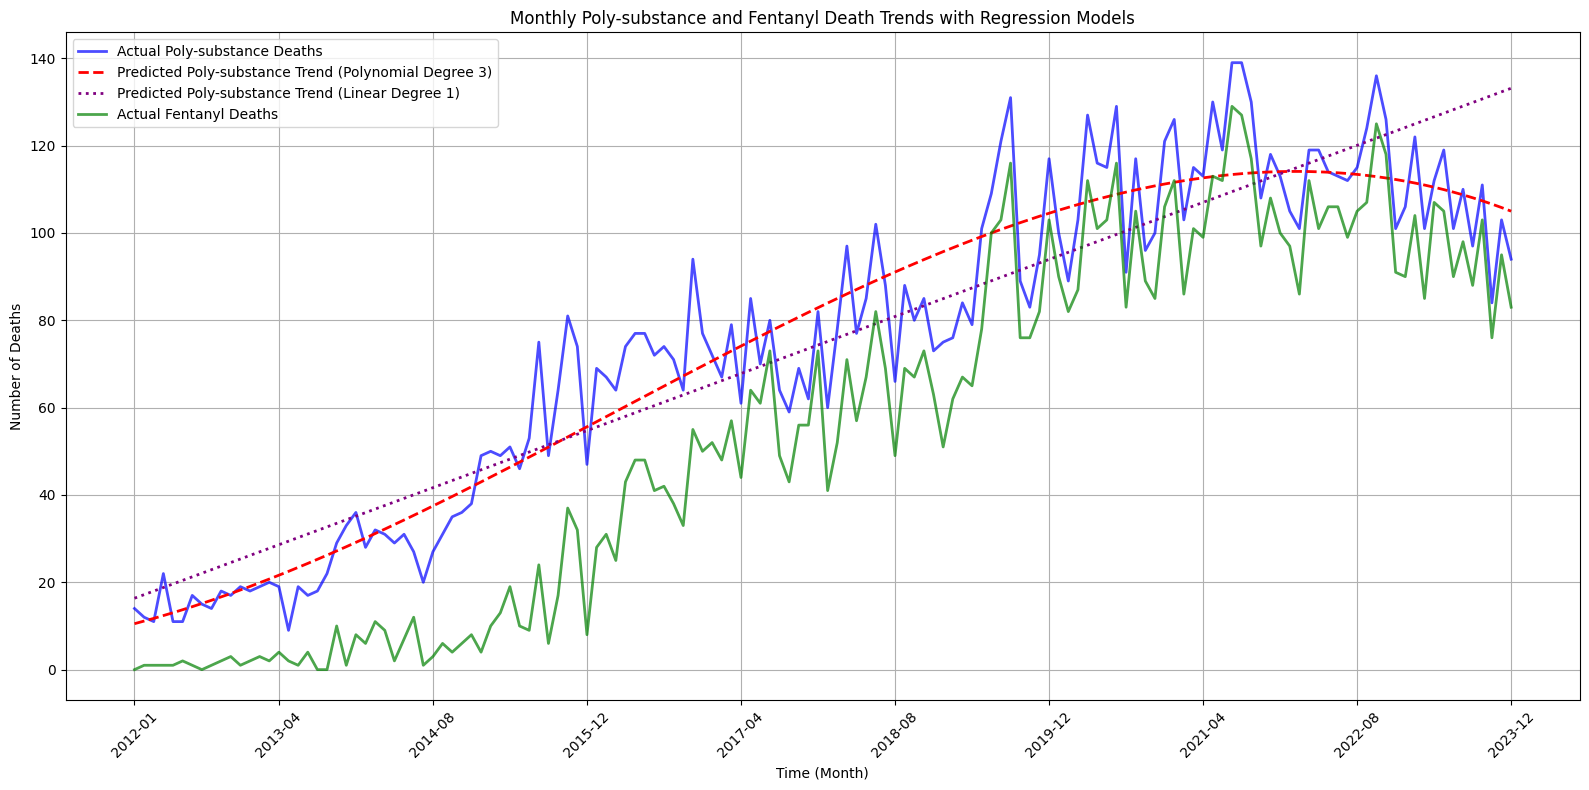

In [ ]:
# 9. Visualize the actual monthly poly-substance deaths and the predicted polynomial trend line.
# Overlay the actual monthly Fentanyl deaths and the simple linear trend on the same plot.

plt.figure(figsize=(16, 8))

# Plot actual monthly poly-substance deaths
plt.plot(monthly_trends['Month'].astype(str), monthly_trends['poly_substance_indicator'],
         label='Actual Poly-substance Deaths', color='blue', alpha=0.7, linewidth=2)

# Plot predicted polynomial trend line (Degree 3)
plt.plot(monthly_trends['Month'].astype(str), y_pred,
         label=f'Predicted Poly-substance Trend (Polynomial Degree {poly_features.degree})', color='red', linestyle='--', linewidth=2)

# Plot predicted simple linear trend line (Degree 1)
plt.plot(monthly_trends['Month'].astype(str), y_pred_linear,
         label='Predicted Poly-substance Trend (Linear Degree 1)', color='purple', linestyle=':', linewidth=2)

# Plot actual monthly Fentanyl deaths
plt.plot(monthly_trends['Month'].astype(str), monthly_trends['Fentanyl'],
         label='Actual Fentanyl Deaths', color='green', alpha=0.7, linewidth=2)

# Set labels and title
plt.xlabel('Time (Month)')
plt.ylabel('Number of Deaths')
plt.title('Monthly Poly-substance and Fentanyl Death Trends with Regression Models')
plt.legend()
plt.grid(True)

# Improve readability of x-axis ticks for time series data
# Show fewer x-axis ticks to prevent overlap
n_ticks = 10 # Number of ticks to display
tick_indices = np.linspace(0, len(monthly_trends) - 1, n_ticks, dtype=int)
plt.xticks(monthly_trends['Month'].astype(str).iloc[tick_indices], rotation=45)
plt.tight_layout()
plt.show()

# Anomaly Detection

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Define the drugs for which we want to detect anomalies
drugs_to_detect = ['Xylazine', 'Gabapentin']

# --- Start of Added Code to ensure monthly_trends has Xylazine and Gabapentin ---
# Create monthly trends for Xylazine and Gabapentin
monthly_drugs_data_for_anomaly = df.groupby('Month')[['Xylazine', 'Gabapentin']].sum().reset_index()

# Merge with the existing monthly_trends. This assumes 'monthly_trends' and 'Month_Numerical' already exist.
monthly_trends = monthly_trends.merge(monthly_drugs_data_for_anomaly, on='Month', how='left')

# Fill any NaNs that might result from months with no activity for a specific drug
monthly_trends[['Xylazine', 'Gabapentin']] = monthly_trends[['Xylazine', 'Gabapentin']].fillna(0)


# Prepare features for anomaly detection (Month_Numerical and drug count)
# Scale features for models sensitive to magnitude (like One-Class SVM)
scaler = StandardScaler()

for drug_col in drugs_to_detect:
    # Create feature set for current drug
    X_anomaly_features = monthly_trends[['Month_Numerical', drug_col]].copy()

    # Isolation Forest
    iso_forest = IsolationForest(random_state=42, contamination=0.05) # Assume ~5% anomalies
    monthly_trends[f'{drug_col}_IF_Anomaly'] = iso_forest.fit_predict(X_anomaly_features)

    # Local Outlier Factor (LOF)
    lof = LocalOutlierFactor(novelty=False, contamination=0.05) # Set novelty=False for in-sample anomaly detection
    monthly_trends[f'{drug_col}_LOF_Anomaly'] = lof.fit_predict(X_anomaly_features)

    # One-Class SVM
    # Scale features specifically for OCSVM as it's sensitive to magnitude
    X_scaled = scaler.fit_transform(X_anomaly_features)
    oc_svm = OneClassSVM(nu=0.05, kernel='rbf', gamma='auto') # nu is upper bound on fraction of training errors and lower bound of fraction of support vectors
    monthly_trends[f'{drug_col}_OCSVM_Anomaly'] = oc_svm.fit_predict(X_scaled)

print("Anomaly detection complete for Xylazine and Gabapentin.")
display(monthly_trends[[col for col in monthly_trends.columns if 'Anomaly' in col or col in drugs_to_detect]].head())

Anomaly detection complete for Xylazine and Gabapentin.


,Xylazine,Gabapentin,Xylazine_IF_Anomaly,Xylazine_LOF_Anomaly,Xylazine_OCSVM_Anomaly,Gabapentin_IF_Anomaly,Gabapentin_LOF_Anomaly,Gabapentin_OCSVM_Anomaly
0,0,0,-1,-1,-1,-1,-1,-1
1,0,0,1,-1,-1,1,-1,-1
2,0,0,1,-1,1,1,-1,1
3,0,0,1,-1,1,1,-1,1
4,0,0,1,-1,1,1,-1,1


/tmp/ipykernel_185/1871315867.py:13: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(anomalies_lof['Month'].astype(str), anomalies_lof[drug_col], color='green', s=100, label=f'Anomaly (LOF)', marker='x', edgecolors='black')


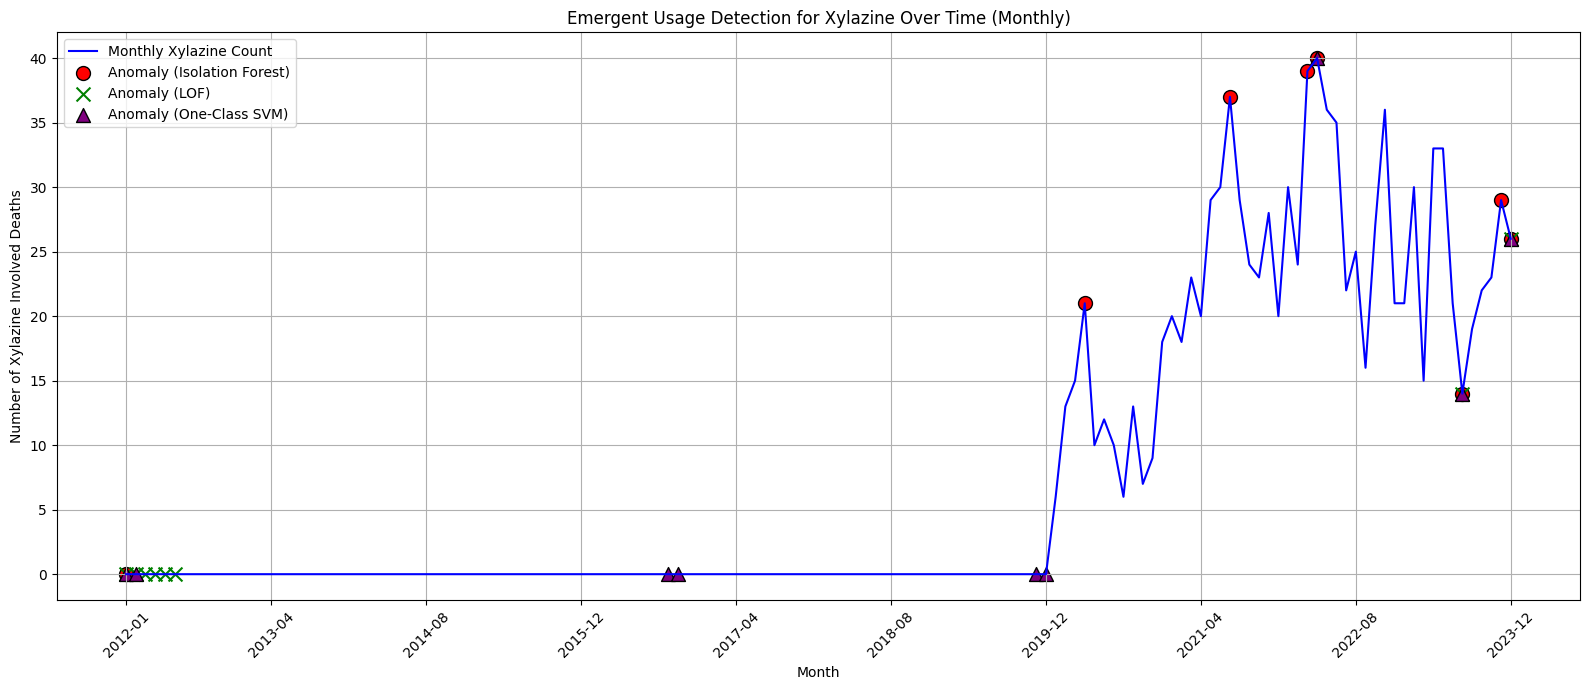

/tmp/ipykernel_185/1871315867.py:13: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(anomalies_lof['Month'].astype(str), anomalies_lof[drug_col], color='green', s=100, label=f'Anomaly (LOF)', marker='x', edgecolors='black')


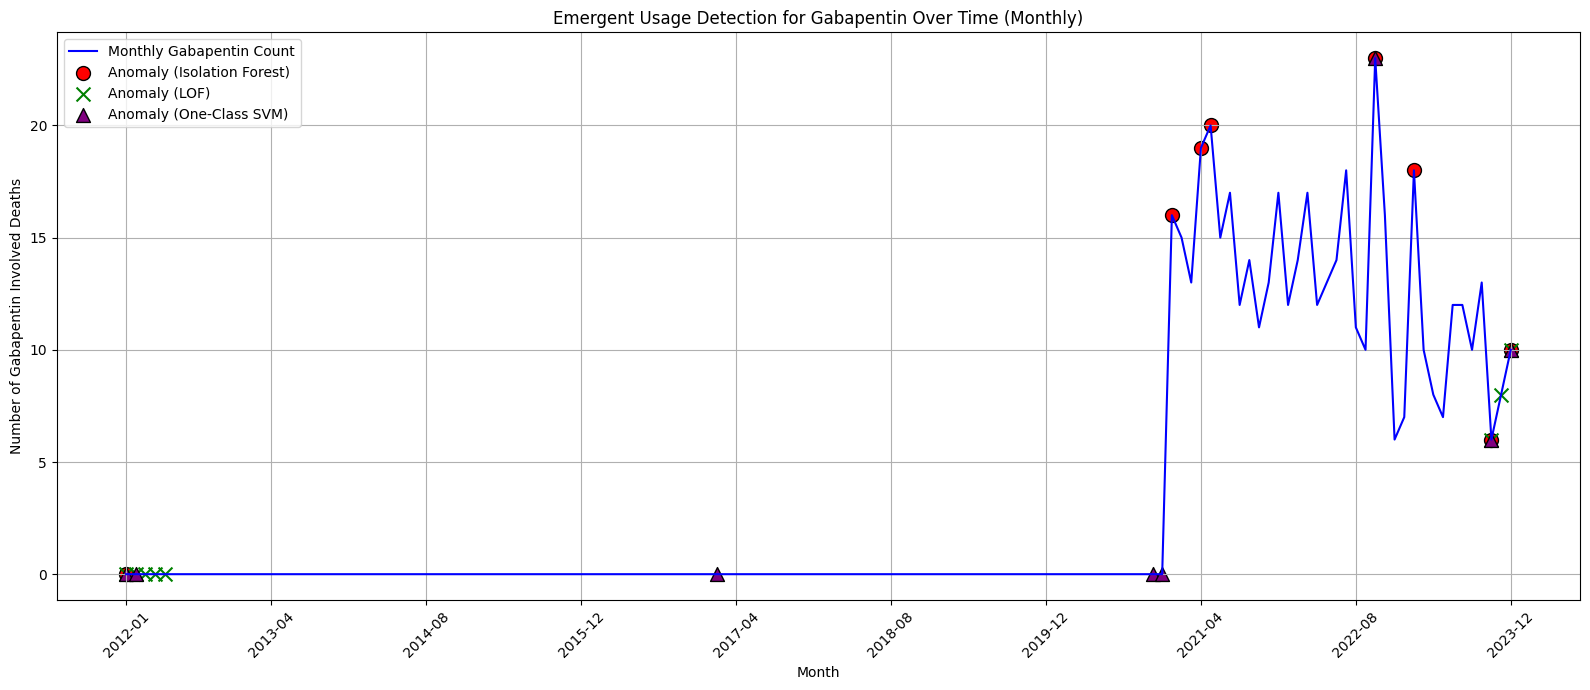

In [ ]:
# Visualize the detected anomalies for each drug

for drug_col in drugs_to_detect:
    plt.figure(figsize=(16, 7))
    sns.lineplot(x=monthly_trends['Month'].astype(str), y=drug_col, data=monthly_trends, label=f'Monthly {drug_col} Count', color='blue')

    # Plot anomalies from Isolation Forest
    anomalies_if = monthly_trends[monthly_trends[f'{drug_col}_IF_Anomaly'] == -1]
    plt.scatter(anomalies_if['Month'].astype(str), anomalies_if[drug_col], color='red', s=100, label=f'Anomaly (Isolation Forest)', marker='o', edgecolors='black')

    # Plot anomalies from Local Outlier Factor
    anomalies_lof = monthly_trends[monthly_trends[f'{drug_col}_LOF_Anomaly'] == -1]
    plt.scatter(anomalies_lof['Month'].astype(str), anomalies_lof[drug_col], color='green', s=100, label=f'Anomaly (LOF)', marker='x', edgecolors='black')

    # Plot anomalies from One-Class SVM
    anomalies_ocsvm = monthly_trends[monthly_trends[f'{drug_col}_OCSVM_Anomaly'] == -1]
    plt.scatter(anomalies_ocsvm['Month'].astype(str), anomalies_ocsvm[drug_col], color='purple', s=100, label=f'Anomaly (One-Class SVM)', marker='^', edgecolors='black')

    plt.title(f'Emergent Usage Detection for {drug_col} Over Time (Monthly)')
    plt.xlabel('Month')
    plt.ylabel(f'Number of {drug_col} Involved Deaths')
    plt.legend()
    plt.grid(True)

    # Improve readability of x-axis ticks for time series data
    n_ticks = 10 # Number of ticks to display
    tick_indices = np.linspace(0, len(monthly_trends) - 1, n_ticks, dtype=int)
    plt.xticks(monthly_trends['Month'].astype(str).iloc[tick_indices], rotation=45)

    plt.tight_layout()
    plt.show()

# Clustering

In [ ]:
# Re-create 'Individual_Drug_Count' and 'poly_substance_indicator' as they are needed for clustering.
# Exclude aggregate drug columns for counting distinct substances
individual_drug_columns = [
    'Heroin', 'Cocaine', 'Fentanyl', 'Fentanyl Analogue', 'Oxycodone',
    'Oxymorphone', 'Ethanol', 'Hydrocodone', 'Benzodiazepine', 'Methadone',
    'Meth/Amphetamine', 'Amphet', 'Tramad', 'Hydromorphone',
    'Morphine (Not Heroin)', 'Xylazine', 'Gabapentin', 'Other', 'Opiate NOS',
    'Heroin/Morph/Codeine', 'Other Opioid', 'Any Opioid'
]

# Ensure all individual_drug_columns exist in df, if not, filter them out
individual_drug_columns = [col for col in individual_drug_columns if col in df.columns]

# Calculate the sum of individual drug involvements
df['Individual_Drug_Count'] = df[individual_drug_columns].sum(axis=1)

# Define poly-substance death if more than one individual drug is involved
df['poly_substance_indicator'] = (df['Individual_Drug_Count'] > 1).astype(int)

print("Recreated 'Individual_Drug_Count' and 'poly_substance_indicator' columns.")
display(df[['Individual_Drug_Count', 'poly_substance_indicator']].head())

Recreated 'Individual_Drug_Count' and 'poly_substance_indicator' columns.


,Individual_Drug_Count,poly_substance_indicator
0,1,0
1,1,0
2,1,0
3,1,0
4,2,1


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define the features to be used for clustering
# Demographic features
demographic_features = ['Age_scaled', 'Sex_Encoded', 'Race_Supergroup']

# Drug involvement features (excluding potentially redundant ones like 'poly_substance_indicator' if Individual_Drug_Count is used, but keeping for now)
# Use the same individual_drug_columns defined previously to ensure consistency
individual_drug_columns = [
    'Heroin', 'Cocaine', 'Fentanyl', 'Fentanyl Analogue', 'Oxycodone',
    'Oxymorphone', 'Ethanol', 'Hydrocodone', 'Benzodiazepine', 'Methadone',
    'Meth/Amphetamine', 'Amphet', 'Tramad', 'Hydromorphone',
    'Morphine (Not Heroin)', 'Xylazine', 'Gabapentin', 'Opiate NOS',
    'Heroin/Morph/Codeine', 'Other Opioid', 'Any Opioid', 'Other'
]
# Filter to only include columns actually present in the DataFrame
individual_drug_columns = [col for col in individual_drug_columns if col in df.columns]

drug_features = individual_drug_columns + ['poly_substance_indicator', 'Individual_Drug_Count']

# Combine all features
all_clustering_features = demographic_features + drug_features

# Filter df to include only these columns for our clustering dataframe
df_clustering = df[all_clustering_features].copy()

print("DataFrame for clustering (first 5 rows) before preprocessing:")
display(df_clustering.head())

DataFrame for clustering (first 5 rows) before preprocessing:


,Age_scaled,Sex_Encoded,Race_Supergroup,Heroin,Cocaine,Fentanyl,Fentanyl Analogue,Oxycodone,Oxymorphone,Ethanol,...,Morphine (Not Heroin),Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,poly_substance_indicator,Individual_Drug_Count
0,-0.553051,0,Black/African American,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,-0.553051,0,White,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,-1.262982,0,White,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,-1.420745,0,White,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,-0.237526,0,White,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,2


In [ ]:
# Define preprocessing steps
# One-hot encode 'Race_Supergroup'
# Scale 'Individual_Drug_Count'

preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), ['Individual_Drug_Count']),
        ('cat_encoder', OneHotEncoder(handle_unknown='ignore'), ['Race_Supergroup'])
    ],
    remainder='passthrough' # Keep other columns (Age_scaled, Sex_Encoded, and binary drug columns)
)

# Create a pipeline for preprocessing
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Fit and transform the data
df_processed_features = pipeline.fit_transform(df_clustering)

# Get feature names after preprocessing
# This can be a bit tricky with ColumnTransformer and remainder='passthrough'

# Get names for scaled numerical features
scaled_cols = ['Individual_Drug_Count']

# Get names for one-hot encoded categorical features
ohe_cols = pipeline.named_steps['preprocessor'].named_transformers_['cat_encoder'].get_feature_names_out(['Race_Supergroup'])

# Get names for passed-through columns (others except 'Individual_Drug_Count' and 'Race_Supergroup')
remainder_cols = [col for col in df_clustering.columns if col not in ['Individual_Drug_Count', 'Race_Supergroup']]

# Combine all feature names in the correct order
feature_names = list(scaled_cols) + list(ohe_cols) + list(remainder_cols)

# Convert to DataFrame
df_clustered_data = pd.DataFrame(df_processed_features, columns=feature_names)

print("Processed features for clustering (first 5 rows):")
display(df_clustered_data.head())
print(f"Shape of clustered data: {df_clustered_data.shape}")

Processed features for clustering (first 5 rows):


,Individual_Drug_Count,Race_Supergroup_Asian,Race_Supergroup_Black/African American,Race_Supergroup_Native American/Alaskan Native,Race_Supergroup_Other,Race_Supergroup_Unknown,Race_Supergroup_White,Age_scaled,Sex_Encoded,Heroin,...,Hydromorphone,Morphine (Not Heroin),Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,poly_substance_indicator
0,-1.592396,0.0,1.0,0.0,0.0,0.0,0.0,-0.553051,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.592396,0.0,0.0,0.0,0.0,0.0,1.0,-0.553051,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.592396,0.0,0.0,0.0,0.0,0.0,1.0,-1.262982,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.592396,0.0,0.0,0.0,0.0,0.0,1.0,-1.420745,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.917027,0.0,0.0,0.0,0.0,0.0,1.0,-0.237526,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


Shape of clustered data: (11981, 32)


Running Elbow Method for K-Means...


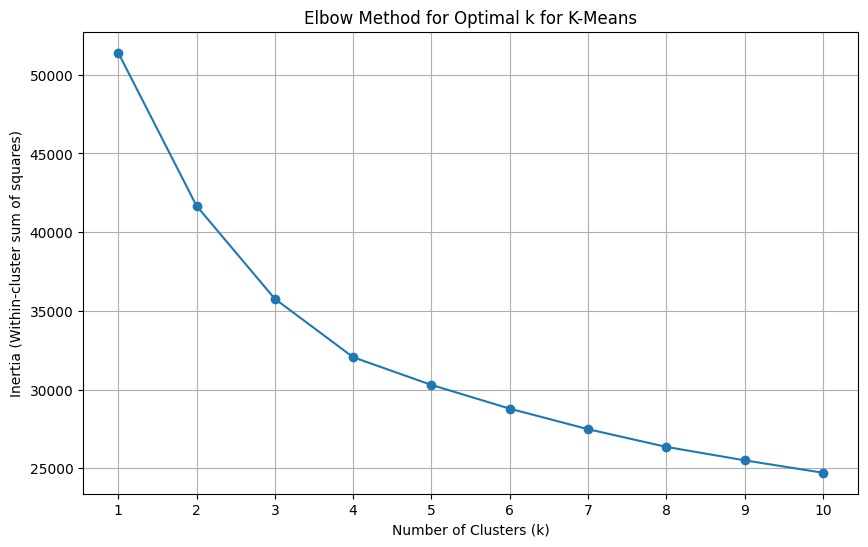

Please examine the plot and identify the 'elbow point' to choose an optimal number of clusters (k).


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming X_cluster (df_clustered_data) is already prepared and contains our features
X_cluster = df_clustered_data

# Determine optimal k using the Elbow Method for K-Means
inertia = []
max_k = 10 # Test up to 10 clusters

print("Running Elbow Method for K-Means...")
for k in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init for robust initialization
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method for Optimal k for K-Means')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

print("Please examine the plot and identify the 'elbow point' to choose an optimal number of clusters (k).")

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming X_cluster (df_clustered_data) is ready
k_optimal = 3 # Chosen based on the Elbow method plot

print(f"Applying K-Means clustering with k = {k_optimal}...")
kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init=10) # n_init for robust initialization
cluster_labels_kmeans = kmeans_model.fit_predict(X_cluster)

# Add cluster labels to the original DataFrame (or a copy for analysis)
df['KMeans_Cluster'] = cluster_labels_kmeans

print("K-Means clustering complete. First 5 rows with cluster labels:")
display(df[['Age', 'Sex_Standardized', 'Race_Supergroup', 'Individual_Drug_Count', 'KMeans_Cluster']].head())

Applying K-Means clustering with k = 3...
K-Means clustering complete. First 5 rows with cluster labels:


,Age,Sex_Standardized,Race_Supergroup,Individual_Drug_Count,KMeans_Cluster
0,37.0,Male,Black/African American,1,1
1,37.0,Male,White,1,1
2,28.0,Male,White,1,0
3,26.0,Male,White,1,0
4,41.0,Male,White,2,0


In [ ]:
print("\n--- K-Means Clustering Performance ---")

# Calculate Silhouette Score
silhouette_avg_kmeans = silhouette_score(X_cluster, cluster_labels_kmeans)
print(f"Silhouette Score for K-Means (k={k_optimal}): {silhouette_avg_kmeans:.4f}")

# Analyze cluster sizes
cluster_sizes_kmeans = df['KMeans_Cluster'].value_counts().sort_index()
print("\nK-Means Cluster Sizes:")
display(cluster_sizes_kmeans)

# Calculate mean of features for each cluster
# CORRECTED: Use df_clustered_data for grouping, and pass df['KMeans_Cluster'] as the grouping key
cluster_means_kmeans = df_clustered_data.groupby(df['KMeans_Cluster']).mean()

print("\nK-Means Cluster Means (first 5 rows and selected columns):")
display(cluster_means_kmeans.head())


--- K-Means Clustering Performance ---
Silhouette Score for K-Means (k=3): 0.1611

K-Means Cluster Sizes:


,count
KMeans_Cluster,
0,4374
1,3631
2,3976



K-Means Cluster Means (first 5 rows and selected columns):


,Individual_Drug_Count,Race_Supergroup_Asian,Race_Supergroup_Black/African American,Race_Supergroup_Native American/Alaskan Native,Race_Supergroup_Other,Race_Supergroup_Unknown,Race_Supergroup_White,Age_scaled,Sex_Encoded,Heroin,...,Hydromorphone,Morphine (Not Heroin),Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,poly_substance_indicator
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.310986,0.008002,0.101052,0.000229,0.006630,0.007087,0.877000,-0.976997,0.000000,0.258573,...,0.003201,0.002058,0.067673,0.013489,0.008230,0.105853,0.008459,0.723365,0.051898,0.917010
1,-0.778084,0.004682,0.176535,0.000275,0.004957,0.004406,0.809143,0.752498,0.001102,0.166345,...,0.004682,0.003305,0.020931,0.019278,0.007161,0.023685,0.007161,0.502892,0.047645,0.764803
2,1.052685,0.004527,0.139085,0.000000,0.005282,0.004779,0.846328,0.387592,0.000503,0.463531,...,0.011569,0.009557,0.177565,0.085513,0.016348,0.415744,0.039990,0.965292,0.097082,1.000000


In [ ]:
print("\n--- K-Means Clustering Performance ---")

# Calculate Silhouette Score
silhouette_avg_kmeans = silhouette_score(X_cluster, cluster_labels_kmeans)
print(f"Silhouette Score for K-Means (k={k_optimal}): {silhouette_avg_kmeans:.4f}")

# Analyze cluster sizes
cluster_sizes_kmeans = df['KMeans_Cluster'].value_counts().sort_index()
print("\nK-Means Cluster Sizes:")
display(cluster_sizes_kmeans)

# Calculate mean of features for each cluster
# CORRECTED: Use df_clustered_data for grouping, and pass df['KMeans_Cluster'] as the grouping key
cluster_means_kmeans = df_clustered_data.groupby(df['KMeans_Cluster']).mean()

print("\nK-Means Cluster Means (first 5 rows and selected columns):")
display(cluster_means_kmeans.head())


--- K-Means Clustering Performance ---
Silhouette Score for K-Means (k=3): 0.1611

K-Means Cluster Sizes:


,count
KMeans_Cluster,
0,4374
1,3631
2,3976



K-Means Cluster Means (first 5 rows and selected columns):


,Individual_Drug_Count,Race_Supergroup_Asian,Race_Supergroup_Black/African American,Race_Supergroup_Native American/Alaskan Native,Race_Supergroup_Other,Race_Supergroup_Unknown,Race_Supergroup_White,Age_scaled,Sex_Encoded,Heroin,...,Hydromorphone,Morphine (Not Heroin),Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,poly_substance_indicator
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.310986,0.008002,0.101052,0.000229,0.006630,0.007087,0.877000,-0.976997,0.000000,0.258573,...,0.003201,0.002058,0.067673,0.013489,0.008230,0.105853,0.008459,0.723365,0.051898,0.917010
1,-0.778084,0.004682,0.176535,0.000275,0.004957,0.004406,0.809143,0.752498,0.001102,0.166345,...,0.004682,0.003305,0.020931,0.019278,0.007161,0.023685,0.007161,0.502892,0.047645,0.764803
2,1.052685,0.004527,0.139085,0.000000,0.005282,0.004779,0.846328,0.387592,0.000503,0.463531,...,0.011569,0.009557,0.177565,0.085513,0.016348,0.415744,0.039990,0.965292,0.097082,1.000000


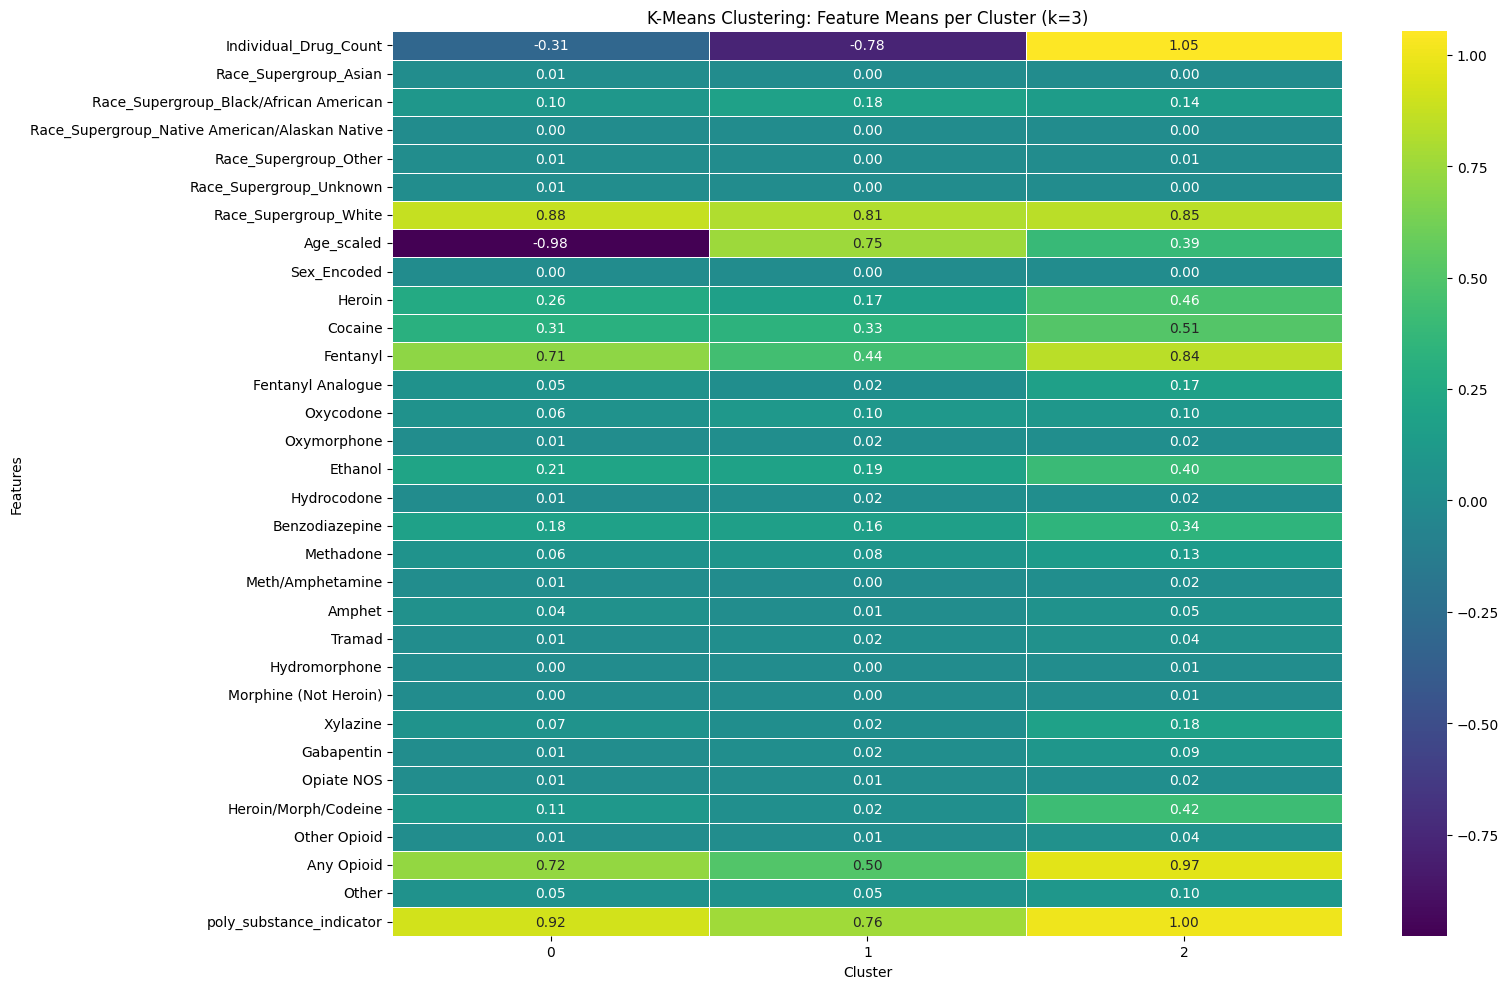

Interpretation of the heatmap:
Each column represents a cluster, and each row represents a feature.
The color intensity and annotated values show the average value of that feature within that cluster.
This helps in characterizing what makes each K-Means cluster distinct (e.g., higher average age, presence of specific drugs, etc.).


In [ ]:
plt.figure(figsize=(16, 10))
sns.heatmap(cluster_means_kmeans.transpose(), cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title(f'K-Means Clustering: Feature Means per Cluster (k={k_optimal})')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.xticks(rotation=0) # Ensure cluster labels are horizontal
plt.yticks(rotation=0) # Ensure feature labels are horizontal
plt.tight_layout()
plt.show()

print("Interpretation of the heatmap:")
print("Each column represents a cluster, and each row represents a feature.")
print("The color intensity and annotated values show the average value of that feature within that cluster.")
print("This helps in characterizing what makes each K-Means cluster distinct (e.g., higher average age, presence of specific drugs, etc.).")

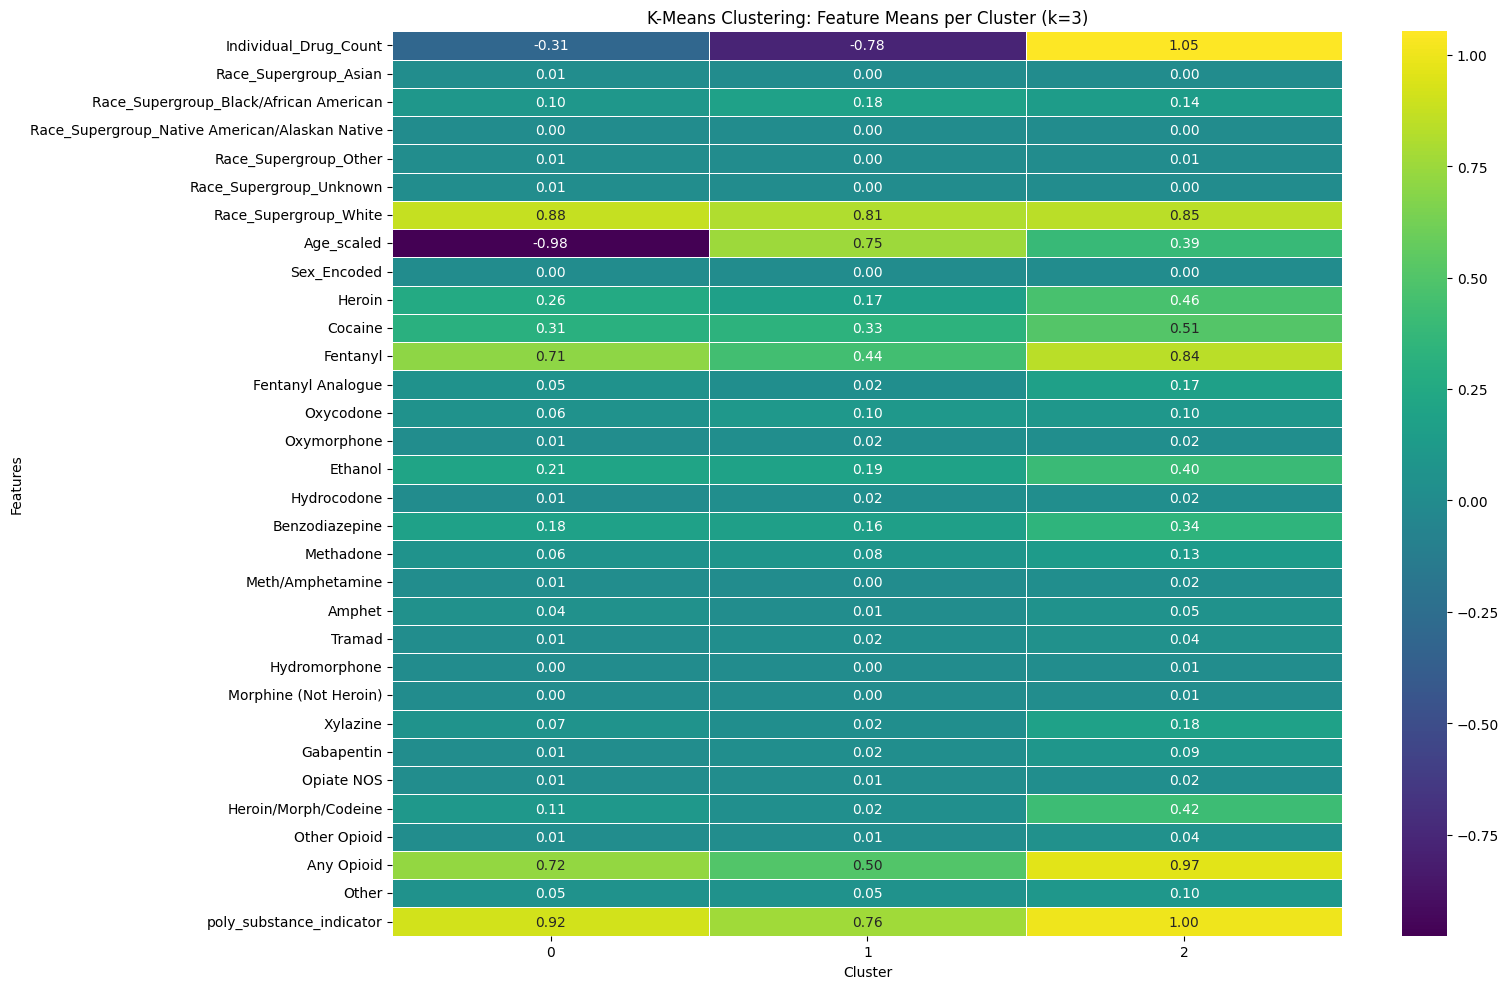

Interpretation of the heatmap:
Each column represents a cluster, and each row represents a feature.
The color intensity and annotated values show the average value of that feature within that cluster.
This helps in characterizing what makes each K-Means cluster distinct (e.g., higher average age, presence of specific drugs, etc.).


In [ ]:
plt.figure(figsize=(16, 10))
sns.heatmap(cluster_means_kmeans.transpose(), cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title(f'K-Means Clustering: Feature Means per Cluster (k={k_optimal})')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.xticks(rotation=0) # Ensure cluster labels are horizontal
plt.yticks(rotation=0) # Ensure feature labels are horizontal
plt.tight_layout()
plt.show()

print("Interpretation of the heatmap:")
print("Each column represents a cluster, and each row represents a feature.")
print("The color intensity and annotated values show the average value of that feature within that cluster.")
print("This helps in characterizing what makes each K-Means cluster distinct (e.g., higher average age, presence of specific drugs, etc.).")

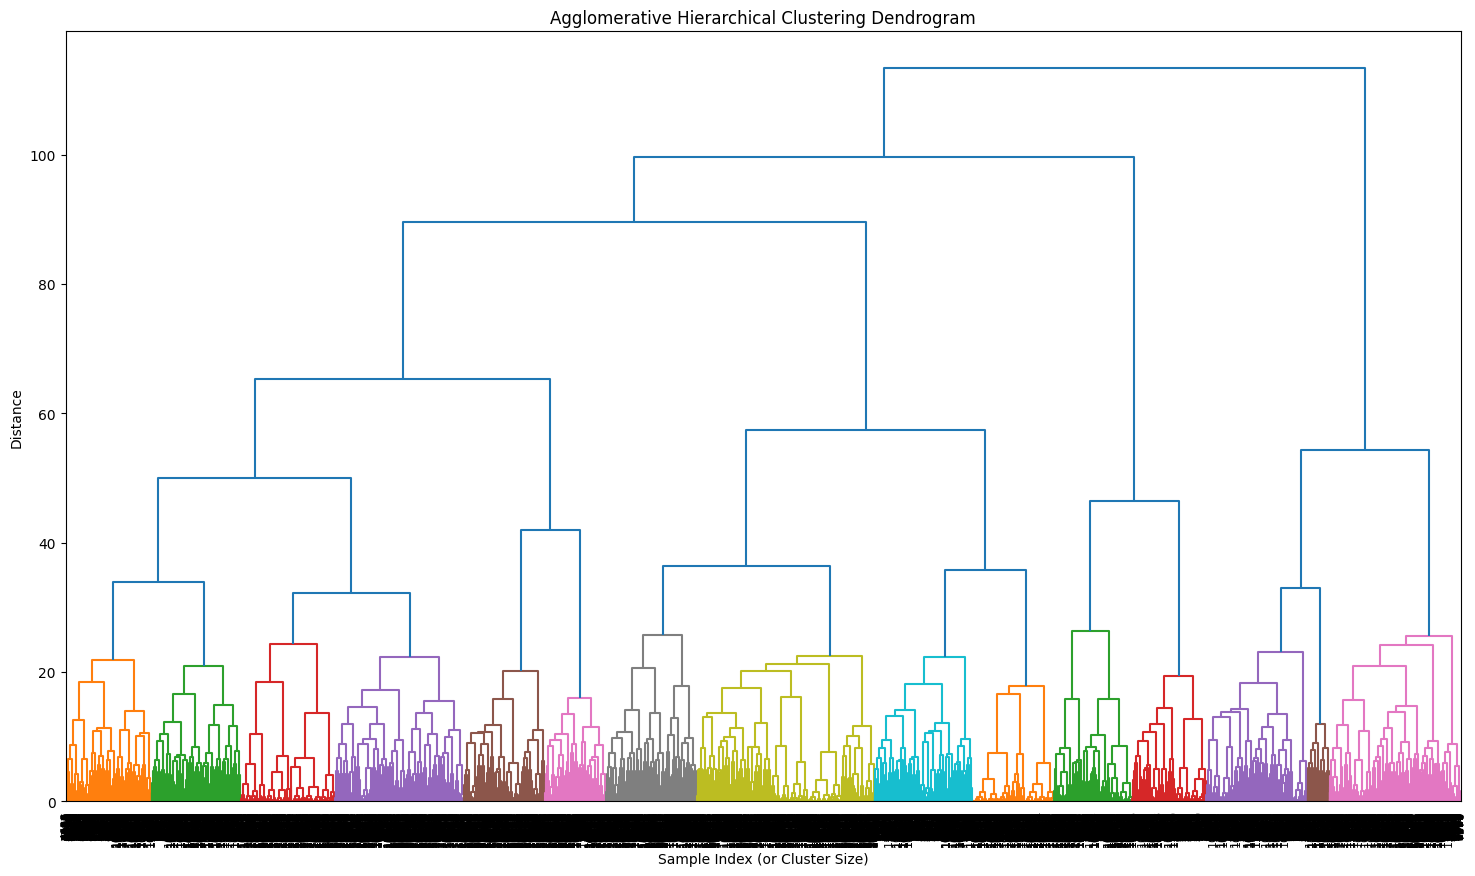

Please examine the dendrogram and suggest a threshold to cut the tree and form clusters.


In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Assuming X_cluster (df_clustered_data) is ready

# Perform hierarchical clustering
# Using 'ward' linkage minimizes the variance within each cluster.
linked = linkage(X_cluster, method='ward')

# Plot the dendrogram
plt.figure(figsize=(18, 10))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=False, # to avoid overcrowding the plot
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=30 # Adjust this threshold to visualize different cluster cuts
)
plt.title('Agglomerative Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index (or Cluster Size)')
plt.ylabel('Distance')
plt.show()

print("Please examine the dendrogram and suggest a threshold to cut the tree and form clusters.")

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming X_cluster (df_clustered_data) is ready
k_optimal_agg = 7 # Chosen based on the dendrogram analysis

print(f"Applying Agglomerative Hierarchical Clustering with n_clusters = {k_optimal_agg}...")
agg_model = AgglomerativeClustering(n_clusters=k_optimal_agg, linkage='ward') # 'ward' linkage used for dendrogram
cluster_labels_agg = agg_model.fit_predict(X_cluster)

# Add cluster labels to the original DataFrame
df['Agglomerative_Cluster'] = cluster_labels_agg

print("Agglomerative Clustering complete. First 5 rows with cluster labels:")
display(df[['Age', 'Sex_Standardized', 'Race_Supergroup', 'Individual_Drug_Count', 'Agglomerative_Cluster']].head())

Applying Agglomerative Hierarchical Clustering with n_clusters = 7...
Agglomerative Clustering complete. First 5 rows with cluster labels:


,Age,Sex_Standardized,Race_Supergroup,Individual_Drug_Count,Agglomerative_Cluster
0,37.0,Male,Black/African American,1,2
1,37.0,Male,White,1,2
2,28.0,Male,White,1,2
3,26.0,Male,White,1,2
4,41.0,Male,White,2,5


In [ ]:
print("\n--- Agglomerative Hierarchical Clustering Performance ---")

# Calculate Silhouette Score
silhouette_avg_agg = silhouette_score(X_cluster, cluster_labels_agg)
print(f"Silhouette Score for Agglomerative Clustering (k={k_optimal_agg}): {silhouette_avg_agg:.4f}")

# Analyze cluster sizes
cluster_sizes_agg = df['Agglomerative_Cluster'].value_counts().sort_index()
print("\nAgglomerative Cluster Sizes:")
display(cluster_sizes_agg)

# Calculate mean of features for each cluster
cluster_means_agg = df_clustered_data.groupby(df['Agglomerative_Cluster']).mean()

print("\nAgglomerative Cluster Means (first 5 rows and selected columns):")
display(cluster_means_agg.head())


--- Agglomerative Hierarchical Clustering Performance ---
Silhouette Score for Agglomerative Clustering (k=7): 0.1124

Agglomerative Cluster Sizes:


,count
Agglomerative_Cluster,
0,3423
1,1220
2,1301
3,2304
4,1063
5,1544
6,1126



Agglomerative Cluster Means (first 5 rows and selected columns):


,Individual_Drug_Count,Race_Supergroup_Asian,Race_Supergroup_Black/African American,Race_Supergroup_Native American/Alaskan Native,Race_Supergroup_Other,Race_Supergroup_Unknown,Race_Supergroup_White,Age_scaled,Sex_Encoded,Heroin,...,Hydromorphone,Morphine (Not Heroin),Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,poly_substance_indicator
Agglomerative_Cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.123276,0.000584,0.002045,0.000000,0.000584,0.000876,0.995910,0.748248,0.001753,0.147531,...,0.007596,0.003506,0.089980,0.052293,0.002045,0.001753,0.011686,0.712825,0.042361,1.000000
1,-0.010261,0.033607,0.899180,0.000000,0.037705,0.028689,0.000820,0.152484,0.000000,0.052459,...,0.004098,0.000000,0.125410,0.054918,0.008197,0.000820,0.018852,0.925410,0.047541,1.000000
2,-1.564363,0.007686,0.224443,0.000769,0.005380,0.006149,0.755573,0.078848,0.000000,0.282859,...,0.000000,0.000769,0.000000,0.002306,0.005380,0.000000,0.004612,0.003075,0.051499,0.064566
3,0.443384,0.000868,0.002170,0.000434,0.001736,0.001302,0.993490,-0.598278,0.000000,0.056858,...,0.003038,0.017795,0.225694,0.071181,0.042101,0.046875,0.036892,0.953125,0.112847,1.000000
4,1.130046,0.011289,0.054563,0.000000,0.001881,0.004704,0.927563,-0.858187,0.000000,0.993415,...,0.012230,0.000000,0.030103,0.009407,0.002822,0.966134,0.017874,1.000000,0.092192,1.000000


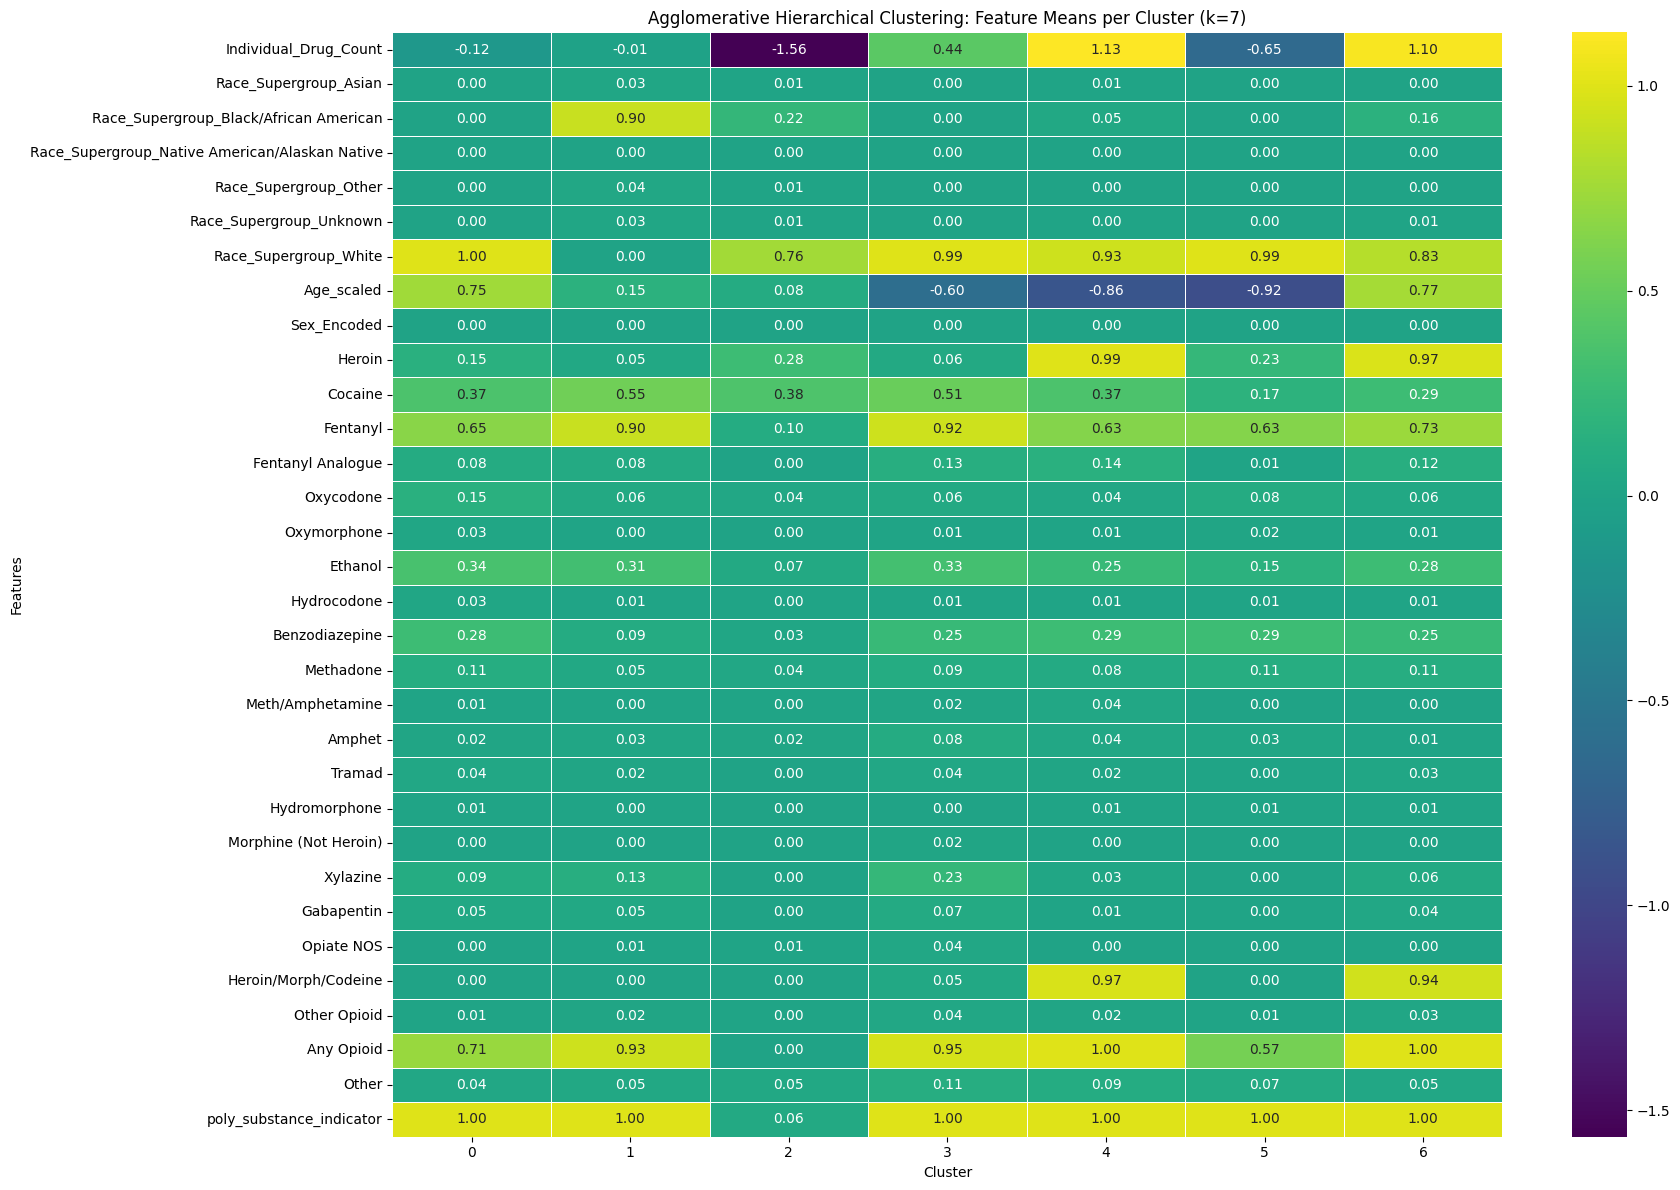

Interpretation of the heatmap:
Each column represents a cluster, and each row represents a feature.
The color intensity and annotated values show the average value of that feature within that cluster.
This helps in characterizing what makes each Agglomerative cluster distinct (e.g., higher average age, presence of specific drugs, etc.).


In [ ]:
plt.figure(figsize=(18, 12))
sns.heatmap(cluster_means_agg.transpose(), cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title(f'Agglomerative Hierarchical Clustering: Feature Means per Cluster (k={k_optimal_agg})')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.xticks(rotation=0) # Ensure cluster labels are horizontal
plt.yticks(rotation=0) # Ensure feature labels are horizontal
plt.tight_layout()
plt.show()

print("Interpretation of the heatmap:")
print("Each column represents a cluster, and each row represents a feature.")
print("The color intensity and annotated values show the average value of that feature within that cluster.")
print("This helps in characterizing what makes each Agglomerative cluster distinct (e.g., higher average age, presence of specific drugs, etc.).")

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming X_cluster (df_clustered_data) is ready

# DBSCAN parameters - these often require tuning
# E.g., choose eps based on k-distance graph, min_samples typically 2*D (where D is dimensionality)
# Starting with conservative values
eps_dbscan = 1.40 # A common starting point, will likely need adjustment
min_samples_dbscan = 100 # Minimum samples for a point to be considered a core point

print(f"Applying DBSCAN clustering with eps={eps_dbscan} and min_samples={min_samples_dbscan}...")
dbscan_model = DBSCAN(eps=eps_dbscan, min_samples=min_samples_dbscan)
cluster_labels_dbscan = dbscan_model.fit_predict(X_cluster)

# Add cluster labels to the original DataFrame
df['DBSCAN_Cluster'] = cluster_labels_dbscan

print("DBSCAN clustering complete. First 5 rows with cluster labels:")
display(df[['Age', 'Sex_Standardized', 'Race_Supergroup', 'Individual_Drug_Count', 'DBSCAN_Cluster']].head())

Applying DBSCAN clustering with eps=1.4 and min_samples=100...
DBSCAN clustering complete. First 5 rows with cluster labels:


,Age,Sex_Standardized,Race_Supergroup,Individual_Drug_Count,DBSCAN_Cluster
0,37.0,Male,Black/African American,1,3
1,37.0,Male,White,1,0
2,28.0,Male,White,1,0
3,26.0,Male,White,1,0
4,41.0,Male,White,2,1


In [ ]:
print("\n--- DBSCAN Clustering Performance ---")

# Analyze cluster sizes and noise points
cluster_sizes_dbscan = df['DBSCAN_Cluster'].value_counts().sort_index()
print("\nDBSCAN Cluster Sizes (Cluster -1 is noise/outliers):")
display(cluster_sizes_dbscan)

# Filter out noise points for Silhouette Score and Mean Calculation
non_noise_indices = cluster_labels_dbscan != -1
X_non_noise = X_cluster[non_noise_indices]
labels_non_noise = cluster_labels_dbscan[non_noise_indices]

# Calculate Silhouette Score only if there are at least 2 clusters (excluding noise)
if len(np.unique(labels_non_noise)) > 1:
    silhouette_avg_dbscan = silhouette_score(X_non_noise, labels_non_noise)
    print(f"Silhouette Score for DBSCAN: {silhouette_avg_dbscan:.4f}")
else:
    print("Silhouette Score not applicable: Less than 2 clusters found (excluding noise).")

# Calculate mean of features for each cluster (excluding noise for mean calculation)
# Ensure cluster -1 (noise) is handled separately or excluded
cluster_means_dbscan = df_clustered_data[non_noise_indices].groupby(labels_non_noise).mean()

print("\nDBSCAN Cluster Means (first 5 rows and selected columns, excluding noise):")
display(cluster_means_dbscan.head())


--- DBSCAN Clustering Performance ---

DBSCAN Cluster Sizes (Cluster -1 is noise/outliers):


,count
DBSCAN_Cluster,
-1,1860
0,979
1,8003
2,959
3,180


Silhouette Score for DBSCAN: 0.1080

DBSCAN Cluster Means (first 5 rows and selected columns, excluding noise):


,Individual_Drug_Count,Race_Supergroup_Asian,Race_Supergroup_Black/African American,Race_Supergroup_Native American/Alaskan Native,Race_Supergroup_Other,Race_Supergroup_Unknown,Race_Supergroup_White,Age_scaled,Sex_Encoded,Heroin,...,Hydromorphone,Morphine (Not Heroin),Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,poly_substance_indicator
0,-1.618610,0.0,0.0,0.0,0.0,0.0,1.0,-0.072592,0.0,0.326864,...,0.000000,0.001021,0.000000,0.001021,0.007150,0.000000,0.000000,0.003064,0.037794,0.0
1,0.125774,0.0,0.0,0.0,0.0,0.0,1.0,-0.060080,0.0,0.320255,...,0.003249,0.000500,0.100087,0.031363,0.000375,0.214794,0.007122,0.847682,0.034862,1.0
2,-0.033907,0.0,1.0,0.0,0.0,0.0,0.0,0.236831,0.0,0.047967,...,0.001043,0.000000,0.103233,0.035454,0.002086,0.019812,0.004171,0.949948,0.022941,1.0
3,-1.626164,0.0,1.0,0.0,0.0,0.0,0.0,0.729208,0.0,0.038889,...,0.000000,0.000000,0.000000,0.005556,0.000000,0.000000,0.000000,0.005556,0.027778,0.0


In [ ]:
# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Convert date to numerical representation for averaging (e.g., ordinal or Unix timestamp)
df['Date_Numerical'] = df['Date'].apply(lambda date: date.toordinal())

# Calculate mean numerical date for each DBSCAN cluster (excluding noise -1)
mean_date_per_cluster = df[df['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')['Date_Numerical'].mean().reset_index()

# Convert numerical date back to datetime object
mean_date_per_cluster['Mean_Date'] = mean_date_per_cluster['Date_Numerical'].apply(lambda ordinal: pd.Timestamp.fromordinal(int(ordinal)))

print("Mean Date for each DBSCAN Cluster (excluding noise):")
display(mean_date_per_cluster[['DBSCAN_Cluster', 'Mean_Date']])

Mean Date for each DBSCAN Cluster (excluding noise):


,DBSCAN_Cluster,Mean_Date
0,0,2016-03-22
1,1,2019-07-26
2,2,2021-04-14
3,3,2018-05-23


Top 12 significant features differentiating DBSCAN clusters:
- Individual_Drug_Count
- Race_Supergroup_Black/African American
- Race_Supergroup_White
- poly_substance_indicator
- Any Opioid
- Fentanyl
- Age_scaled
- Cocaine
- Ethanol
- Heroin
- Benzodiazepine
- Heroin/Morph/Codeine


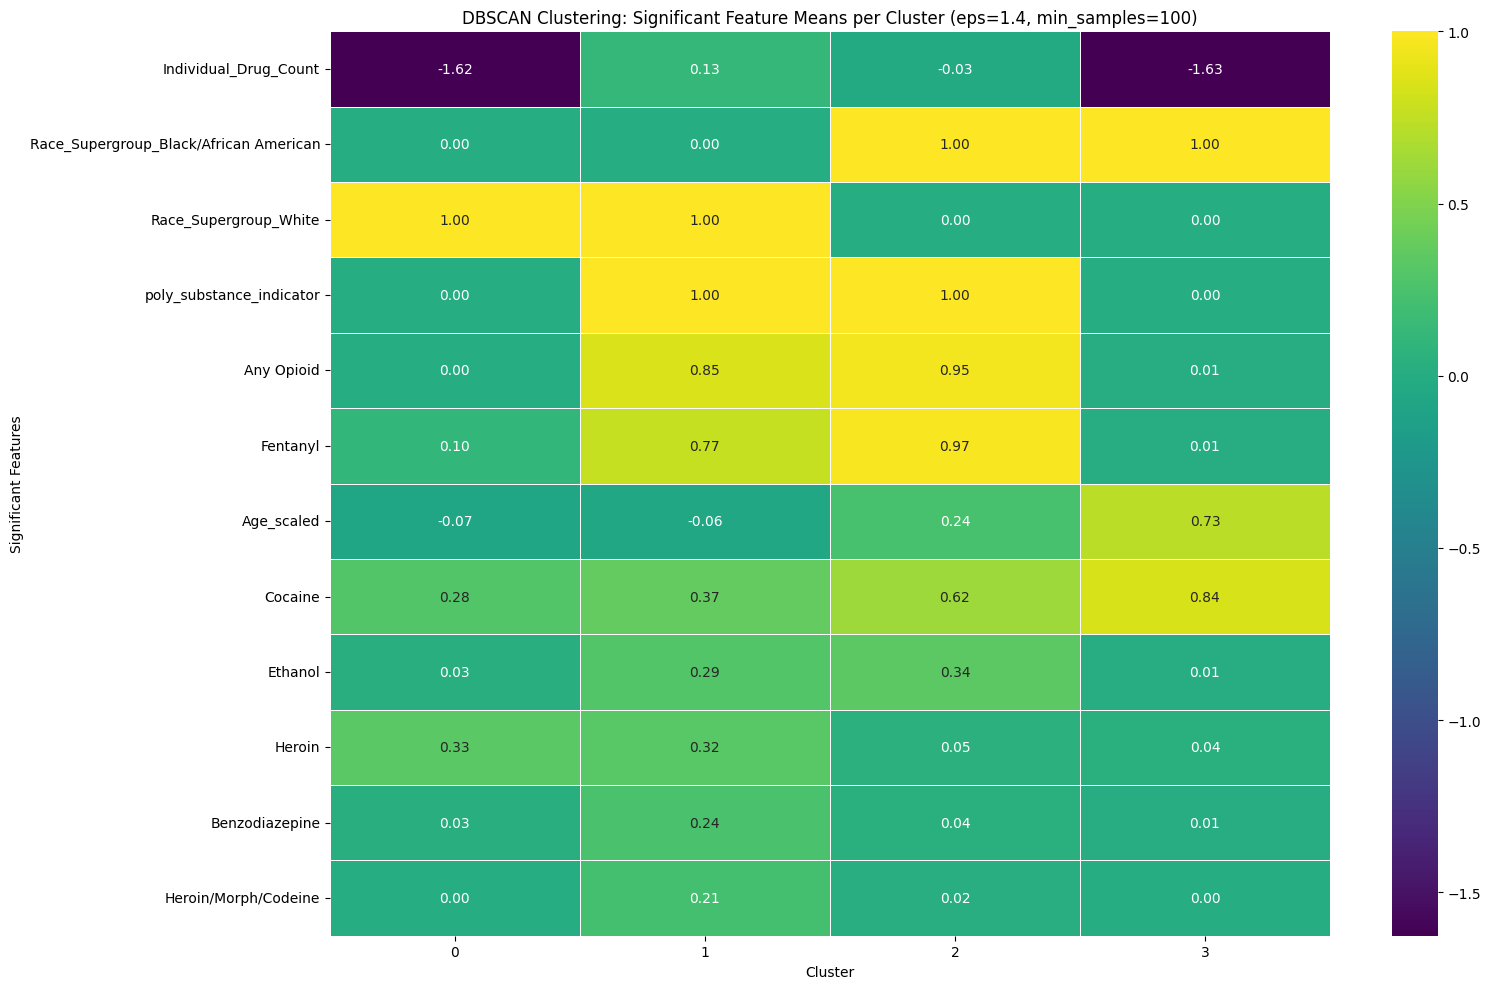

Interpretation of the focused heatmap:
This heatmap highlights the features that vary most significantly across the DBSCAN clusters, 
making it easier to identify the core characteristics that distinguish each cluster.


In [ ]:
# Identify significant features for the heatmap
# We can define 'significant' by a high standard deviation across cluster means

# Ensure cluster_means_dbscan is defined from the last run. If not, recompute (excluding noise)
non_noise_indices = df['DBSCAN_Cluster'] != -1
labels_non_noise = df['DBSCAN_Cluster'][non_noise_indices]
cluster_means_dbscan = df_clustered_data[non_noise_indices].groupby(labels_non_noise).mean()

# Calculate the standard deviation of each feature's mean across clusters
feature_std_dev = cluster_means_dbscan.std(axis=0)

# Sort features by standard deviation and select the top N or those above a threshold
# Let's select features with std dev above 0.1 as a starting point, or top 10 if fewer
significant_features = feature_std_dev[feature_std_dev > 0.1].sort_values(ascending=False).index.tolist()

# If no features meet the threshold, or too few, take top N most variable features
if not significant_features or len(significant_features) < 5:
    significant_features = feature_std_dev.nlargest(10).index.tolist()

print(f"Top {len(significant_features)} significant features differentiating DBSCAN clusters:")
for feature in significant_features:
    print(f"- {feature}")

# Create a focused heatmap using only the significant features
if not cluster_means_dbscan.empty and significant_features:
    plt.figure(figsize=(16, 10))
    sns.heatmap(cluster_means_dbscan[significant_features].transpose(), cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
    plt.title(f'DBSCAN Clustering: Significant Feature Means per Cluster (eps={eps_dbscan}, min_samples={min_samples_dbscan})')
    plt.xlabel('Cluster')
    plt.ylabel('Significant Features')
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("Interpretation of the focused heatmap:")
    print("This heatmap highlights the features that vary most significantly across the DBSCAN clusters, ")
    print("making it easier to identify the core characteristics that distinguish each cluster.")
else:
    print("Not enough significant features or clusters to generate a focused heatmap.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Date' column is in datetime format and 'Month' exists
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

# Filter out noise points (-1) for clearer visualization of clusters
clustered_df = df[df['DBSCAN_Cluster'] != -1].copy()

# Group by Month and DBSCAN_Cluster and count occurrences
cluster_monthly_counts = clustered_df.groupby(['Month', 'DBSCAN_Cluster']).size().reset_index(name='Count')

# Convert 'Month' Period objects to string for plotting on x-axis
cluster_monthly_counts['Month_Str'] = cluster_monthly_counts['Month'].astype(str)

print("Monthly counts for each DBSCAN cluster (first 5 rows):")
display(cluster_monthly_counts.head())

Monthly counts for each DBSCAN cluster (first 5 rows):


,Month,DBSCAN_Cluster,Count,Month_Str
0,2012-01,0,15,2012-01
1,2012-01,1,9,2012-01
2,2012-01,3,2,2012-01
3,2012-02,0,12,2012-02
4,2012-02,1,5,2012-02


In [ ]:
# Calculate rolling mean for smoothing
# Adjust the window size as needed for desired smoothness
window_size = 6 # Example: 3-month rolling mean

cluster_monthly_counts['Smoothed_Count'] = cluster_monthly_counts.groupby('DBSCAN_Cluster')['Count'].transform(lambda x: x.rolling(window=window_size, min_periods=1).mean())

print(f"Monthly counts with {window_size}-month rolling mean (first 5 rows):")
display(cluster_monthly_counts.head())

Monthly counts with 6-month rolling mean (first 5 rows):


,Month,DBSCAN_Cluster,Count,Month_Str,Smoothed_Count
0,2012-01,0,15,2012-01,15.0
1,2012-01,1,9,2012-01,9.0
2,2012-01,3,2,2012-01,2.0
3,2012-02,0,12,2012-02,13.5
4,2012-02,1,5,2012-02,7.0


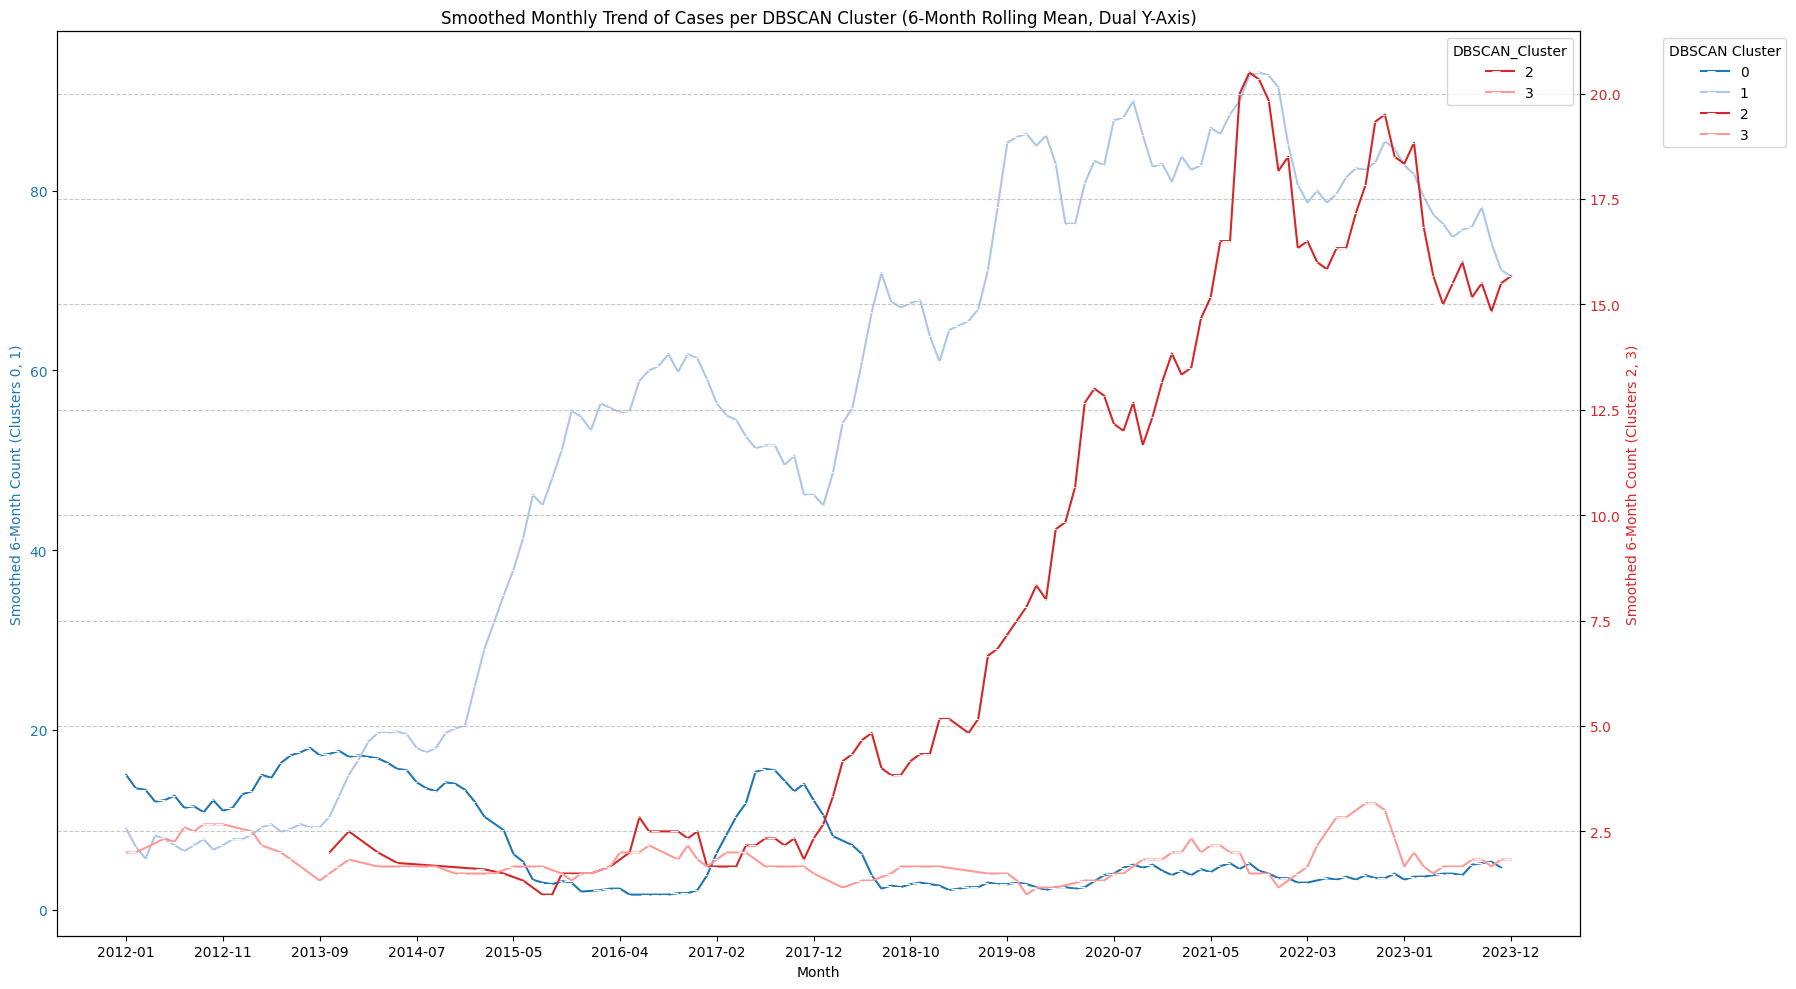

In [ ]:
plt.figure(figsize=(18, 10))

# Create the first Y-axis for Cluster 0 and 1
ax1 = sns.lineplot(
    data=cluster_monthly_counts[cluster_monthly_counts['DBSCAN_Cluster'].isin([0, 1])],
    x='Month_Str',
    y='Smoothed_Count',
    hue='DBSCAN_Cluster',
    marker=False, # Removed markers
    palette=['#1f77b4', '#aec7e8'], # Shades of blue for clusters 0 and 1
    ax=plt.gca() # Use current axes
)
ax1.set_xlabel('Month')
ax1.set_ylabel(f'Smoothed {window_size}-Month Count (Clusters 0, 1)', color='#1f77b4') # Adjust color to match palette
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Create a second Y-axis for Cluster 2 and 3
ax2 = ax1.twinx()
sns.lineplot(
    data=cluster_monthly_counts[cluster_monthly_counts['DBSCAN_Cluster'].isin([2, 3])],
    x='Month_Str',
    y='Smoothed_Count',
    hue='DBSCAN_Cluster',
    marker=False, # Removed markers
    palette=['#d62728', '#ff9896'], # Shades of red for clusters 2 and 3
    ax=ax2
)
ax2.set_ylabel(f'Smoothed {window_size}-Month Count (Clusters 2, 3)', color='#d62728') # Adjust color to match palette
ax2.tick_params(axis='y', labelcolor='#d62728')

plt.title(f'Smoothed Monthly Trend of Cases per DBSCAN Cluster ({window_size}-Month Rolling Mean, Dual Y-Axis)')
plt.grid(True, linestyle='--', alpha=0.7)

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, title='DBSCAN Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve readability of x-axis ticks for time series data
n_ticks = 15 # Number of ticks to display
tick_indices = np.linspace(0, len(cluster_monthly_counts['Month_Str'].unique()) - 1, n_ticks, dtype=int)
plt.xticks(cluster_monthly_counts['Month_Str'].unique()[tick_indices], rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Classification

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# --- 1. Data Preparation for City-Level Analysis ---
# Standardize 'Residence City'
if 'Residence City' in df.columns:
    df['Residence City'] = df['Residence City'].astype(str).str.strip().str.title()
    print("Standardized 'Residence City' column.")

# Define relevant drug columns for analysis
synthetic_drugs = ['Fentanyl', 'Fentanyl Analogue', 'Xylazine']
opioid_related_drugs = [
    'Heroin', 'Heroin death certificate (DC)', 'Oxycodone', 'Oxymorphone',
    'Hydrocodone', 'Methadone', 'Tramad', 'Hydromorphone', 'Morphine (Not Heroin)',
    'Opiate NOS', 'Heroin/Morph/Codeine', 'Other Opioid', 'Any Opioid'
]
prescription_drugs = ['Ethanol', 'Benzodiazepine'] # Defined as per user's 'Low Risk' criteria
other_drugs = ['Cocaine', 'Meth/Amphetamine', 'Amphet', 'Gabapentin', 'Other']

# Combine all drug columns for prevalence calculation
all_drug_cols = list(set(synthetic_drugs + opioid_related_drugs + prescription_drugs + other_drugs))
# Filter to only include columns actually present in the DataFrame
all_drug_cols = [col for col in all_drug_cols if col in df.columns]

# Ensure 'Age' is numeric
if 'Age' in df.columns:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    # Impute missing ages with median if any were introduced by coercion
    if df['Age'].isnull().any():
        df['Age'].fillna(df['Age'].median(), inplace=True)
    print("Ensured 'Age' column is numeric and imputed missing values.")
else:
    print("Warning: 'Age' column not found.")

# Ensure 'Date' is datetime and create 'Month' for growth rate calculation
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

# --- 2. Calculate City-Level Metrics ---

temp_cols_to_drop = [] # Keep track of temporary columns to drop later

if synthetic_drugs and all(col in df.columns for col in synthetic_drugs):
    df['synthetic_drug_involvement_indicator'] = df[synthetic_drugs].any(axis=1).astype(int)
    temp_cols_to_drop.append('synthetic_drug_involvement_indicator')
else:
    df['synthetic_drug_involvement_indicator'] = 0 # Default to 0 if columns missing

if opioid_related_drugs and all(col in df.columns for col in opioid_related_drugs):
    df['opioid_drug_involvement_indicator'] = df[opioid_related_drugs].any(axis=1).astype(int)
    temp_cols_to_drop.append('opioid_drug_involvement_indicator')
else:
    df['opioid_drug_involvement_indicator'] = 0

if prescription_drugs and all(col in df.columns for col in prescription_drugs):
    df['prescription_drug_involvement_indicator'] = df[prescription_drugs].any(axis=1).astype(int)
    temp_cols_to_drop.append('prescription_drug_involvement_indicator')
else:
    df['prescription_drug_involvement_indicator'] = 0

# Group by 'Residence City' and calculate required metrics
city_metrics = df.groupby('Residence City').agg(
    total_deaths=('Date', 'count'), # Use any non-null column to count rows
    avg_age=('Age', 'mean'),
    **{f'{drug}_prevalence': (drug, 'mean') for drug in all_drug_cols}, # Mean of binary is prevalence
    synthetic_drug_involvement_count=('synthetic_drug_involvement_indicator', 'sum'),
    poly_substance_deaths=('poly_substance_indicator', 'sum'),
    opioid_drug_involvement_count=('opioid_drug_involvement_indicator', 'sum'),
    prescription_drug_involvement_count=('prescription_drug_involvement_indicator', 'sum')
).reset_index()

# Calculate prevalence for synthetic, poly-substance, opioid, and prescription drugs
city_metrics['synthetic_drug_prevalence'] = city_metrics['synthetic_drug_involvement_count'] / city_metrics['total_deaths']
city_metrics['poly_substance_prevalence'] = city_metrics['poly_substance_deaths'] / city_metrics['total_deaths']
city_metrics['opioid_drug_prevalence'] = city_metrics['opioid_drug_involvement_count'] / city_metrics['total_deaths']
city_metrics['prescription_drug_prevalence'] = city_metrics['prescription_drug_involvement_count'] / city_metrics['total_deaths']

# Remove intermediate counts
city_metrics.drop(columns=[
    'synthetic_drug_involvement_count',
    'poly_substance_deaths',
    'opioid_drug_involvement_count',
    'prescription_drug_involvement_count'
], inplace=True)

# Drop the temporary indicator columns from df
df.drop(columns=temp_cols_to_drop, errors='ignore', inplace=True)

# --- Calculate Growth Rate of Drug Deaths per City ---
city_growth_rates = []
for city in df['Residence City'].unique():
    city_df = df[df['Residence City'] == city].copy()
    monthly_deaths = city_df.groupby('Month').size().reset_index(name='death_count')

    if len(monthly_deaths) > 1:
        # Convert 'Month' to a numerical representation (e.g., months since start)
        monthly_deaths['Month_Numerical'] = (monthly_deaths['Month'] - monthly_deaths['Month'].min()).apply(lambda x: x.n)

        X_growth = monthly_deaths[['Month_Numerical']]
        y_growth = monthly_deaths['death_count']

        # Fit linear regression to get the slope (growth rate)
        model_growth = LinearRegression()
        model_growth.fit(X_growth, y_growth)
        growth_rate = model_growth.coef_[0]
    else:
        growth_rate = 0 # No growth rate if only one data point

    city_growth_rates.append({'Residence City': city, 'growth_rate_deaths_per_month': growth_rate})

growth_df = pd.DataFrame(city_growth_rates)

# Merge growth rates back into city_metrics
city_metrics = pd.merge(city_metrics, growth_df, on='Residence City', how='left')
city_metrics['growth_rate_deaths_per_month'] = city_metrics['growth_rate_deaths_per_month'].fillna(0) # Fill NaN for cities with no data points

print("\nCity-level metrics calculated with growth rates:")
display(city_metrics.head())
print(f"Total cities analyzed: {city_metrics.shape[0]}")

# --- 3. Refined Risk Classification ---
# Define thresholds for classification using quantiles
synthetic_q3 = city_metrics['synthetic_drug_prevalence'].quantile(0.75)
poly_q3 = city_metrics['poly_substance_prevalence'].quantile(0.75)
opioid_q2 = city_metrics['opioid_drug_prevalence'].quantile(0.50) # Median for consistent use
prescription_q3 = city_metrics['prescription_drug_prevalence'].quantile(0.75)
total_deaths_q1 = city_metrics['total_deaths'].quantile(0.25) # Bottom 25% for 'sporadic deaths'

def classify_risk(row):
    is_high_synthetic = (row['synthetic_drug_prevalence'] >= synthetic_q3)
    is_high_poly = (row['poly_substance_prevalence'] >= poly_q3)
    is_high_opioid = (row['opioid_drug_prevalence'] >= opioid_q2)
    is_high_prescription = (row['prescription_drug_prevalence'] >= prescription_q3)
    is_sporadic_deaths = (row['total_deaths'] <= total_deaths_q1)

    if is_high_synthetic and is_high_poly:
        return 'High Risk'
    elif is_high_prescription and is_sporadic_deaths:
        return 'Low Risk'
    elif is_high_opioid:
        return 'Medium Risk'
    else:
        return 'Low Risk'

city_metrics['Risk_Category'] = city_metrics.apply(classify_risk, axis=1)

print("\nCity risk classification complete:")
display(city_metrics[['Residence City', 'total_deaths', 'avg_age',
                      'synthetic_drug_prevalence', 'poly_substance_prevalence',
                      'opioid_drug_prevalence', 'prescription_drug_prevalence',
                      'growth_rate_deaths_per_month', 'Risk_Category']].head())

print("\nRisk Category distribution:")
display(city_metrics['Risk_Category'].value_counts())

# Display cities by risk category
print("\nHigh Risk Cities (top 5 by synthetic prevalence):")
display(city_metrics[city_metrics['Risk_Category'] == 'High Risk'].sort_values(by='synthetic_drug_prevalence', ascending=False).head())

print("\nMedium Risk Cities (top 5 by opioid prevalence):")
display(city_metrics[city_metrics['Risk_Category'] == 'Medium Risk'].sort_values(by='opioid_drug_prevalence', ascending=False).head())

print("\nLow Risk Cities (top 5 by prescription prevalence and sporadic deaths):")
display(city_metrics[city_metrics['Risk_Category'] == 'Low Risk'].sort_values(by='prescription_drug_prevalence', ascending=False).head())

print("\nUndefined/Other Risk Cities (top 5 by total deaths):")
display(city_metrics[city_metrics['Risk_Category'] == 'Undefined/Other'].sort_values(by='total_deaths', ascending=False).head())

Standardized 'Residence City' column.
Ensured 'Age' column is numeric and imputed missing values.

City-level metrics calculated with growth rates:


,Residence City,total_deaths,avg_age,Tramad_prevalence,Heroin/Morph/Codeine_prevalence,Oxycodone_prevalence,Hydromorphone_prevalence,Hydrocodone_prevalence,Benzodiazepine_prevalence,Other_prevalence,...,Opiate NOS_prevalence,Heroin_prevalence,Ethanol_prevalence,Heroin death certificate (DC)_prevalence,Fentanyl_prevalence,synthetic_drug_prevalence,poly_substance_prevalence,opioid_drug_prevalence,prescription_drug_prevalence,growth_rate_deaths_per_month
0,Agawam,1,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0
1,Akron,2,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.5,0.0,1.0,1.0,1.0,1.0,0.5,0.0
2,Alfred Station,1,65.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,Allen,1,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0
4,Allston,1,37.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Total cities analyzed: 536

City risk classification complete:


,Residence City,total_deaths,avg_age,synthetic_drug_prevalence,poly_substance_prevalence,opioid_drug_prevalence,prescription_drug_prevalence,growth_rate_deaths_per_month,Risk_Category
0,Agawam,1,46.0,1.0,1.0,1.0,0.0,0.0,High Risk
1,Akron,2,54.0,1.0,1.0,1.0,0.5,0.0,High Risk
2,Alfred Station,1,65.0,0.0,1.0,1.0,0.0,0.0,Medium Risk
3,Allen,1,54.0,1.0,1.0,1.0,1.0,0.0,High Risk
4,Allston,1,37.0,0.0,0.0,1.0,0.0,0.0,Medium Risk



Risk Category distribution:


...

,Residence City,total_deaths,avg_age,Tramad_prevalence,Heroin/Morph/Codeine_prevalence,Oxycodone_prevalence,Hydromorphone_prevalence,Hydrocodone_prevalence,Benzodiazepine_prevalence,Other_prevalence,...,Heroin_prevalence,Ethanol_prevalence,Heroin death certificate (DC)_prevalence,Fentanyl_prevalence,synthetic_drug_prevalence,poly_substance_prevalence,opioid_drug_prevalence,prescription_drug_prevalence,growth_rate_deaths_per_month,Risk_Category
2,Alfred Station,1,65.000,0.000,0.000,1.000,0.0,0.0,0.000,0.000,...,0.00,0.000,0.000,0.00,0.00,1.00,1.0,0.00,0.0,Medium Risk
4,Allston,1,37.000,0.000,0.000,0.000,0.0,0.0,0.000,0.000,...,0.00,0.000,0.000,0.00,0.00,0.00,1.0,0.00,0.0,Medium Risk
5,Amenia,1,51.000,0.000,0.000,0.000,0.0,0.0,0.000,0.000,...,1.00,0.000,0.000,0.00,0.00,1.00,1.0,0.00,0.0,Medium Risk
7,Andover,4,44.500,0.000,0.000,0.500,0.0,0.0,0.250,0.000,...,0.25,0.500,0.000,0.75,0.75,1.00,1.0,0.50,0.0,Medium Risk
18,Baltic,8,37.375,0.125,0.125,0.125,0.0,0.0,0.125,0.125,...,0.50,0.125,0.125,0.50,0.50,0.75,1.0,0.25,0.0,Medium Risk



Low Risk Cities (top 5 by prescription prevalence and sporadic deaths):


,Residence City,total_deaths,avg_age,Tramad_prevalence,Heroin/Morph/Codeine_prevalence,Oxycodone_prevalence,Hydromorphone_prevalence,Hydrocodone_prevalence,Benzodiazepine_prevalence,Other_prevalence,...,Heroin_prevalence,Ethanol_prevalence,Heroin death certificate (DC)_prevalence,Fentanyl_prevalence,synthetic_drug_prevalence,poly_substance_prevalence,opioid_drug_prevalence,prescription_drug_prevalence,growth_rate_deaths_per_month,Risk_Category
10,Arlington Heights,1,72.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,Low Risk
15,Aventura,1,29.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,Low Risk
12,Astoria,2,32.0,0.0,0.0,0.5,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1.0,0.0,Low Risk
214,Lakeville,1,33.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,Low Risk
123,East Woodstock,1,58.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,Low Risk



Undefined/Other Risk Cities (top 5 by total deaths):


,Residence City,total_deaths,avg_age,Tramad_prevalence,Heroin/Morph/Codeine_prevalence,Oxycodone_prevalence,Hydromorphone_prevalence,Hydrocodone_prevalence,Benzodiazepine_prevalence,Other_prevalence,...,Heroin_prevalence,Ethanol_prevalence,Heroin death certificate (DC)_prevalence,Fentanyl_prevalence,synthetic_drug_prevalence,poly_substance_prevalence,opioid_drug_prevalence,prescription_drug_prevalence,growth_rate_deaths_per_month,Risk_Category


In [ ]:
print("\nSummary of Key Metrics by Risk Category:")
display(city_metrics.groupby('Risk_Category')[[
    'total_deaths', 'avg_age',
    'synthetic_drug_prevalence', 'poly_substance_prevalence',
    'opioid_drug_prevalence', 'prescription_drug_prevalence',
    'growth_rate_deaths_per_month'
]].mean().sort_values(by='total_deaths', ascending=False))

print("\nFurther breakdown of drug prevalence across all cities (average):")
# Dynamically select all _prevalence columns
prevalence_cols = [col for col in city_metrics.columns if '_prevalence' in col]
display(city_metrics[prevalence_cols].mean().sort_values(ascending=False))


Summary of Key Metrics by Risk Category:


,total_deaths,avg_age,synthetic_drug_prevalence,poly_substance_prevalence,opioid_drug_prevalence,prescription_drug_prevalence,growth_rate_deaths_per_month
Risk_Category,,,,,,,
Low Risk,51.788018,42.201455,0.485061,0.828720,0.757357,0.522593,0.002594
Medium Risk,4.621359,39.675847,0.381851,0.819646,1.000000,0.299937,-0.000055
High Risk,1.236111,40.336960,1.000000,1.000000,0.943287,0.459028,0.000000



Further breakdown of drug prevalence across all cities (average):


,0
poly_substance_prevalence,0.896000
opioid_drug_prevalence,0.878911
Any Opioid_prevalence,0.713586
synthetic_drug_prevalence,0.672740
Fentanyl_prevalence,0.670732
prescription_drug_prevalence,0.454191
Cocaine_prevalence,0.347705
Heroin_prevalence,0.300311
Ethanol_prevalence,0.263260
Benzodiazepine_prevalence,0.255871


In [ ]:
# 1. Create a DataFrame X by dropping the 'Residence City' and 'Risk_Category' columns from city_metrics
X = city_metrics.drop(columns=['Residence City', 'Risk_Category']).copy()

# 2. Create a Series y containing the 'Risk_Category' column from city_metrics
y = city_metrics['Risk_Category']

# 3. Identify any remaining categorical columns in X
categorical_cols_X = X.select_dtypes(include='object').columns

# 4. If categorical columns are found, apply one-hot encoding to them and update X
if not categorical_cols_X.empty:
    print(f"Categorical columns identified for one-hot encoding: {list(categorical_cols_X)}")
    X = pd.get_dummies(X, columns=categorical_cols_X, drop_first=True)
    print("One-hot encoding applied to categorical features in X.")
else:
    print("No categorical columns found in X, proceeding with numerical features.")

print("\nFeatures (X) after preprocessing:")
display(X.head())
print(f"Shape of X: {X.shape}")

print("\nTarget (y) variable:")
display(y.head())
print(f"Shape of y: {y.shape}")

No categorical columns found in X, proceeding with numerical features.

Features (X) after preprocessing:


,total_deaths,avg_age,Tramad_prevalence,Heroin/Morph/Codeine_prevalence,Oxycodone_prevalence,Hydromorphone_prevalence,Hydrocodone_prevalence,Benzodiazepine_prevalence,Other_prevalence,Methadone_prevalence,...,Opiate NOS_prevalence,Heroin_prevalence,Ethanol_prevalence,Heroin death certificate (DC)_prevalence,Fentanyl_prevalence,synthetic_drug_prevalence,poly_substance_prevalence,opioid_drug_prevalence,prescription_drug_prevalence,growth_rate_deaths_per_month
0,1,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0
1,2,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.5,0.0,1.0,1.0,1.0,1.0,0.5,0.0
2,1,65.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,1,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0
4,1,37.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Shape of X: (536, 30)

Target (y) variable:


,Risk_Category
0,High Risk
1,High Risk
2,Medium Risk
3,High Risk
4,Medium Risk


Shape of y: (536,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Instantiate LabelEncoder
label_encoder = LabelEncoder()

# Fit the encoder to the y Series and transform it to numerical labels
y_encoded = label_encoder.fit_transform(y)

# Assign the transformed values back to y for consistency
y = pd.Series(y_encoded, index=y.index, name=y.name)

print("Target variable 'Risk_Category' encoded to numerical format.")

# Display the first 5 unique encoded values of y and their counts
print("\nUnique encoded values and their counts:")
display(y.value_counts().sort_index().head())

# Display the mapping for verification
print("\nOriginal to Encoded mapping:")
display(pd.DataFrame({'Original Category': label_encoder.classes_, 'Encoded Value': label_encoder.transform(label_encoder.classes_)}))

Target variable 'Risk_Category' encoded to numerical format.

Unique encoded values and their counts:


,count
Risk_Category,
0,216
1,217
2,103



Original to Encoded mapping:


,Original Category,Encoded Value
0,High Risk,0
1,Low Risk,1
2,Medium Risk,2


In [ ]:
import pandas as pd

# 1. Define a list named selected_features
selected_features = [
    'Fentanyl_prevalence','total_deaths'
]

# 2. Create a new DataFrame X_new by selecting these selected_features columns from the existing city_metrics DataFrame.
X_new = city_metrics[selected_features].copy()

# 3. Verify that all columns in X_new are numerical.
non_numerical_cols = X_new.select_dtypes(exclude=np.number).columns.tolist()
if non_numerical_cols:
    print(f"Warning: Non-numerical columns found in X_new: {non_numerical_cols}")
    # Attempt to convert to numeric, coercing errors to NaN
    for col in non_numerical_cols:
        X_new[col] = pd.to_numeric(X_new[col], errors='coerce')
    # Drop rows with NaN if conversion failed for critical features, or impute
    # For this task, we'll assume they should be numeric and raise a warning.
    print("Attempted to convert non-numerical columns to numeric.")
else:
    print("All selected features are numerical.")

print("\nNew Feature Set (X_new):")
# 4. Display the first 5 rows of X_new
display(X_new.head())
# 5. Print the shape of X_new
print(f"Shape of X_new: {X_new.shape}")

All selected features are numerical.

New Feature Set (X_new):


,Fentanyl_prevalence,total_deaths
0,1.0,1
1,1.0,2
2,0.0,1
3,1.0,1
4,0.0,1


Shape of X_new: (536, 2)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets using X_new and y
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.3, random_state=42, stratify=y)

print("Data split into training and testing sets (new features).")
print(f"Shape of X_train_new: {X_train_new.shape}")
print(f"Shape of y_train_new: {y_train_new.shape}")
print(f"Shape of X_test_new: {X_test_new.shape}")
print(f"Shape of y_test_new: {y_test_new.shape}")

Data split into training and testing sets (new features).
Shape of X_train_new: (375, 2)
Shape of y_train_new: (375,)
Shape of X_test_new: (161, 2)
Shape of y_test_new: (161,)


New RandomForestClassifier model trained successfully with selected features.
New Model Accuracy: 0.8199
New Model Precision (Macro Avg): 0.7684
New Model Recall (Macro Avg): 0.7613
New Model F1-Score (Macro Avg): 0.7639

New Model Classification Report:
              precision    recall  f1-score   support

   High Risk       0.98      1.00      0.99        65
    Low Risk       0.76      0.80      0.78        65
 Medium Risk       0.56      0.48      0.52        31

    accuracy                           0.82       161
   macro avg       0.77      0.76      0.76       161
weighted avg       0.81      0.82      0.82       161


New Model Confusion Matrix:


,High Risk,Low Risk,Medium Risk
High Risk,65,0,0
Low Risk,1,52,12
Medium Risk,0,16,15


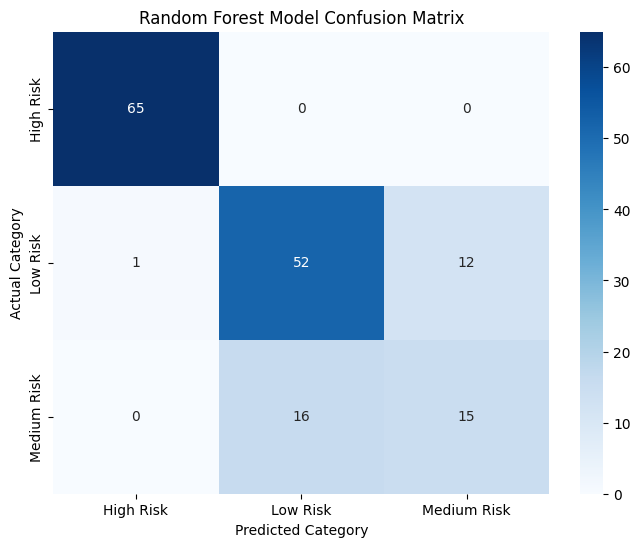

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
# Instantiate a new RandomForestClassifier model
# Using random_state for reproducibility
new_model = RandomForestClassifier(random_state=42)

# Train the new model using the X_train_new and y_train_new datasets
new_model.fit(X_train_new, y_train_new)

print("New RandomForestClassifier model trained successfully with selected features.")

# 1. Make predictions on the test set using the model
y_pred_new = new_model.predict(X_test_new)

# 3. Calculate and print evaluation metrics for the model
accuracy_new = accuracy_score(y_test_new, y_pred_new)
precision_new = precision_score(y_test_new, y_pred_new, average='macro', zero_division=0)
recall_new = recall_score(y_test_new, y_pred_new, average='macro', zero_division=0)
f1_new = f1_score(y_test_new, y_pred_new, average='macro', zero_division=0)

print(f"New Model Accuracy: {accuracy_new:.4f}")
print(f"New Model Precision (Macro Avg): {precision_new:.4f}")
print(f"New Model Recall (Macro Avg): {recall_new:.4f}")
print(f"New Model F1-Score (Macro Avg): {f1_new:.4f}")

# 4. Generate and print the classification report for the model
print("\nNew Model Classification Report:")
print(classification_report(y_test_new, y_pred_new, target_names=label_encoder.classes_, zero_division=0))

# 5. Generate and store the confusion matrix for the model
cm_new = confusion_matrix(y_test_new, y_pred_new)
print("\nNew Model Confusion Matrix:")
display(pd.DataFrame(cm_new, index=label_encoder.classes_, columns=label_encoder.classes_))

# Create a figure and an axes object for the plot
plt.figure(figsize=(8, 6))

# Generate a heatmap of the confusion matrix
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

# Set labels and title
plt.title('Random Forest Model Confusion Matrix')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()


SVM model trained successfully with selected features.
SVM Model Accuracy: 0.6460
SVM Model Precision (Macro Avg): 0.4916
SVM Model Recall (Macro Avg): 0.5333
SVM Model F1-Score (Macro Avg): 0.4785

SVM Model Classification Report:
              precision    recall  f1-score   support

   High Risk       0.55      1.00      0.71        65
    Low Risk       0.93      0.60      0.73        65
 Medium Risk       0.00      0.00      0.00        31

    accuracy                           0.65       161
   macro avg       0.49      0.53      0.48       161
weighted avg       0.60      0.65      0.58       161


SVM Model Confusion Matrix:


,High Risk,Low Risk,Medium Risk
High Risk,65,0,0
Low Risk,26,39,0
Medium Risk,28,3,0


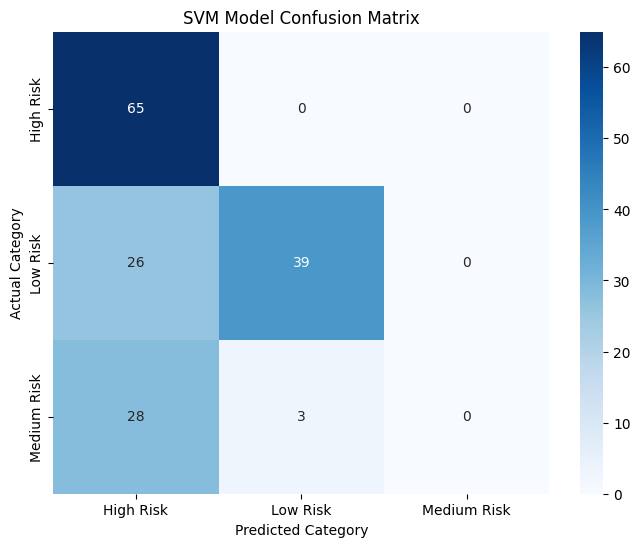

In [ ]:
from sklearn.svm import SVC

# Instantiate an SVC model
# Using random_state for reproducibility
svm_model = SVC(random_state=42)

# Train the SVM model using the X_train_new and y_train_new datasets
svm_model.fit(X_train_new, y_train_new)

print("SVM model trained successfully with selected features.")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

# 1. Make predictions on the test set using the new SVM model
y_pred_svm = svm_model.predict(X_test_new)

# 2. Calculate and print evaluation metrics for the SVM model
accuracy_svm = accuracy_score(y_test_new, y_pred_svm)
precision_svm = precision_score(y_test_new, y_pred_svm, average='macro', zero_division=0)
recall_svm = recall_score(y_test_new, y_pred_svm, average='macro', zero_division=0)
f1_svm = f1_score(y_test_new, y_pred_svm, average='macro', zero_division=0)

print(f"SVM Model Accuracy: {accuracy_svm:.4f}")
print(f"SVM Model Precision (Macro Avg): {precision_svm:.4f}")
print(f"SVM Model Recall (Macro Avg): {recall_svm:.4f}")
print(f"SVM Model F1-Score (Macro Avg): {f1_svm:.4f}")

# 3. Generate and print the classification report for the SVM model
print("\nSVM Model Classification Report:")
print(classification_report(y_test_new, y_pred_svm, target_names=label_encoder.classes_, zero_division=0))

# 4. Generate and store the confusion matrix for the SVM model
cm_svm = confusion_matrix(y_test_new, y_pred_svm)
print("\nSVM Model Confusion Matrix:")
display(pd.DataFrame(cm_svm, index=label_encoder.classes_, columns=label_encoder.classes_))

# Create a figure and an axes object for the plot
plt.figure(figsize=(8, 6))

# Generate a heatmap of the confusion matrix
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

# Set labels and title
plt.title('SVM Model Confusion Matrix')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()

Gradient Boosting model trained successfully with selected features.
Gradient Boosting Model Accuracy: 0.8323
Gradient Boosting Model Precision (Macro Avg): 0.7858
Gradient Boosting Model Recall (Macro Avg): 0.7659
Gradient Boosting Model F1-Score (Macro Avg): 0.7713

Gradient Boosting Model Classification Report:
              precision    recall  f1-score   support

   High Risk       0.98      1.00      0.99        65
    Low Risk       0.76      0.85      0.80        65
 Medium Risk       0.61      0.45      0.52        31

    accuracy                           0.83       161
   macro avg       0.79      0.77      0.77       161
weighted avg       0.82      0.83      0.82       161


Gradient Boosting Model Confusion Matrix:


,High Risk,Low Risk,Medium Risk
High Risk,65,0,0
Low Risk,1,55,9
Medium Risk,0,17,14


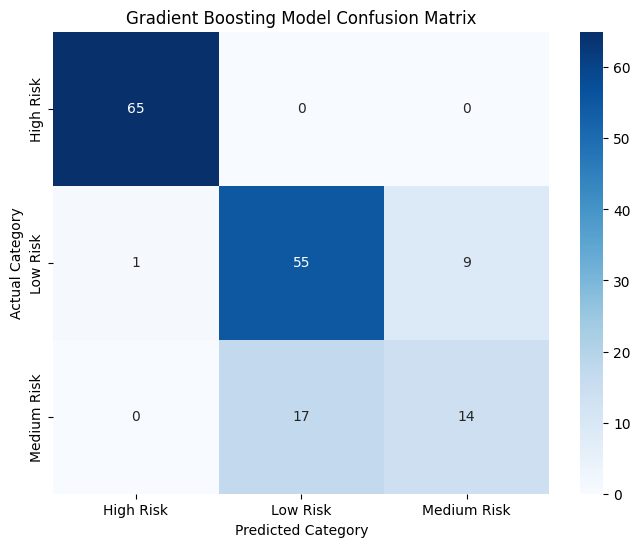

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Instantiate a GradientBoostingClassifier model
# Using random_state=42 for reproducibility
gradient_boosting_model = GradientBoostingClassifier(random_state=42)

# Train the Gradient Boosting model using the X_train_new and y_train_new datasets
gradient_boosting_model.fit(X_train_new, y_train_new)

print("Gradient Boosting model trained successfully with selected features.")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

# 1. Make predictions on the test set using the new Gradient Boosting model
y_pred_gb = gradient_boosting_model.predict(X_test_new)

# 2. Calculate and print evaluation metrics for the Gradient Boosting model
accuracy_gb = accuracy_score(y_test_new, y_pred_gb)
precision_gb = precision_score(y_test_new, y_pred_gb, average='macro', zero_division=0)
recall_gb = recall_score(y_test_new, y_pred_gb, average='macro', zero_division=0)
f1_gb = f1_score(y_test_new, y_pred_gb, average='macro', zero_division=0)

print(f"Gradient Boosting Model Accuracy: {accuracy_gb:.4f}")
print(f"Gradient Boosting Model Precision (Macro Avg): {precision_gb:.4f}")
print(f"Gradient Boosting Model Recall (Macro Avg): {recall_gb:.4f}")
print(f"Gradient Boosting Model F1-Score (Macro Avg): {f1_gb:.4f}")

# 3. Generate and print the classification report for the Gradient Boosting model
print("\nGradient Boosting Model Classification Report:")
print(classification_report(y_test_new, y_pred_gb, target_names=label_encoder.classes_, zero_division=0))

# 4. Generate and store the confusion matrix for the Gradient Boosting model
cm_gb = confusion_matrix(y_test_new, y_pred_gb)
print("\nGradient Boosting Model Confusion Matrix:")
display(pd.DataFrame(cm_gb, index=label_encoder.classes_, columns=label_encoder.classes_))

import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and an axes object for the plot
plt.figure(figsize=(8, 6))

# Generate a heatmap of the confusion matrix
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

# Set labels and title
plt.title('Gradient Boosting Model Confusion Matrix')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()

### Clustering Model Comparison

Here's a summary of the performance metrics for the K-Means, Agglomerative Hierarchical, and DBSCAN clustering models:

**1. K-Means Clustering (k = 3):**
- **Silhouette Score:** `0.1611`
- **Cluster Sizes:**
  - Cluster 0: `4374`
  - Cluster 1: `3631`
  - Cluster 2: `3976`

**2. Agglomerative Hierarchical Clustering (k = 7):**
- **Silhouette Score:** `0.1124`
- **Cluster Sizes:**
  - Cluster 0: `3423`
  - Cluster 1: `1220`
  - Cluster 2: `1301`
  - Cluster 3: `2304`
  - Cluster 4: `1063`
  - Cluster 5: `1544`
  - Cluster 6: `1126`

**3. DBSCAN Clustering (eps = 1.4, min_samples = 100):**
- **Silhouette Score:** `0.1080` (excluding noise points)
- **Cluster Sizes (Cluster -1 is noise/outliers):**
  - Cluster -1: `1860` (Noise)
  - Cluster 0: `979`
  - Cluster 1: `8003`
  - Cluster 2: `959`
  - Cluster 3: `180`

**Interpretation:**
- **K-Means** achieved the highest Silhouette Score among the three, suggesting its clusters are slightly better defined in terms of separation and cohesion given the chosen `k=3`. The cluster sizes are relatively balanced.
- **Agglomerative Clustering** with `k=7` yielded a lower Silhouette Score. This model produced a larger number of clusters with varying sizes.
- **DBSCAN** had the lowest Silhouette Score (among valid clusters), but it uniquely identifies noise points (`-1` cluster). It found one very large cluster (Cluster 1) and several smaller ones, indicating dense regions of data points while marking sparse regions as noise. This can be beneficial for discovering naturally occurring, irregularly shaped clusters.

Each model has its strengths and weaknesses, and the 'best' model depends on the specific goals of the clustering task (e.g., identifying distinct groups vs. finding dense regions and outliers).

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming cm_new (RandomForest), cm_svm (SVM), and cm_gb (GradientBoosting) are already defined
# And label_encoder.classes_ contains the class names

fig, axes = plt.subplots(1, 3, figsize=(24, 7)) # 1 row, 3 columns

# Plotting Random Forest Confusion Matrix
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted Category')
axes[0].set_ylabel('Actual Category')

# Plotting SVM Confusion Matrix
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[1])
axes[1].set_title('SVM Confusion Matrix')
axes[1].set_xlabel('Predicted Category')
axes[1].set_ylabel('Actual Category')

# Plotting Gradient Boosting Confusion Matrix
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[2])
axes[2].set_title('Gradient Boosting Confusion Matrix')
axes[2].set_xlabel('Predicted Category')
axes[2].set_ylabel('Actual Category')

plt.tight_layout()
plt.show()